## ESM-2

In [ ]:
pip install fair-esm  # latest release, OR:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 311.6 kB/s eta 0:00:00


In [ ]:
import torch
import esm

# Load ESM-2 model
model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t30_150M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t30_150M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D-contact-regression.pt


ESM2(
  (embed_tokens): Embedding(33, 640, padding_idx=1)
  (layers): ModuleList(
    (0-29): 30 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=640, out_features=640, bias=True)
        (v_proj): Linear(in_features=640, out_features=640, bias=True)
        (q_proj): Linear(in_features=640, out_features=640, bias=True)
        (out_proj): Linear(in_features=640, out_features=640, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=640, out_features=2560, bias=True)
      (fc2): Linear(in_features=2560, out_features=640, bias=True)
      (final_layer_norm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=600, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((640,), eps=1e-05, elementw

In [ ]:
# Prepare data (first 2 sequences from ESMStructuralSplitDataset superfamily / 4)
data = [
    ("protein1", "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG"),
    ("protein2", "KALTARQQEVFDLIRDHISQTGMPPTRAEIAQRLGFRSPNAAEEHLKALARKGVIEIVSGASRGIRLLQEE"),
    ("protein2 with mask","KALTARQQEVFDLIRD<mask>ISQTGMPPTRAEIAQRLGFRSPNAAEEHLKALARKGVIEIVSGASRGIRLLQEE"),
    ("protein3",  "K A <mask> I S Q"),
]
batch_labels, batch_strs, batch_tokens = batch_converter(data)
batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

In [ ]:
# Extract per-residue representations (on CPU)
with torch.no_grad():
    results = model(batch_tokens, repr_layers=[30], return_contacts=False)
token_representations = results["representations"][30]

In [ ]:
results["representations"][30].shape

torch.Size([4, 73, 640])

In [ ]:
# Generate per-sequence representations via averaging
# NOTE: token 0 is always a beginning-of-sequence token, so the first residue is token 1.
sequence_representations = []
for i, tokens_len in enumerate(batch_lens):
    sequence_representations.append(token_representations[i, 1 : tokens_len - 1].mean(0))

## FLIP Dataset Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/CBMF 4761 "

/content/drive/MyDrive/CBMF 4761 


In [ ]:
data_path = '/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/four_mutations_full_data.csv'

In [ ]:
import pandas as pd

df = pd.read_csv(data_path)

/tmp/ipykernel_2496/628945171.py:3: DtypeWarning: Columns (8,10,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


In [ ]:
df

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
0,VDGV,0,92735,338346,1.000000,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
1,ADGV,1,34,43,0.061910,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGADGEWTYD...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CDGV,1,850,641,0.242237,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGCDGEWTYD...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DDGV,1,63,63,0.006472,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGDDGEWTYD...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,EDGV,1,841,190,0.032719,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGEDGEWTYD...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149356,YYYR,4,203,1,0.001350,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYYEWTYD...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149357,YYYS,4,186,3,0.004421,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYYEWTYD...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149358,YYYT,4,181,14,0.021200,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYYEWTYD...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149359,YYYW,4,30,1,0.009136,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYYEWTYD...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.columns)

Index(['Variants', 'HD', 'Count input', 'Count selected', 'Fitness',
       'sequence', 'keep', 'one_vs_rest', 'one_vs_rest_validation',
       'two_vs_rest', 'two_vs_rest_validation', 'three_vs_rest',
       'three_vs_rest_validation', 'sampled', 'sampled_validation',
       'low_vs_high', 'low_vs_high_validation'],
      dtype='object')


In [ ]:
df[df['one_vs_rest']=='train']

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
0,VDGV,0,92735,338346,1.000000,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
8,IDGV,1,405,1460,1.445905,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGIDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,True,test,NaN
10,LDGV,1,937,3230,1.690164,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLDGEWTYD...,True,train,NaN,train,NaN,train,NaN,test,NaN,test,NaN
11,MDGV,1,547,1136,1.170550,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGMDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,True,test,NaN
18,VAGV,1,173,1108,2.401243,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVAGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
19,VCGV,1,378,1981,1.838187,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVCGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
25,VDGA,1,825,5942,1.372949,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,True,train,NaN,train,NaN,train,True,test,NaN
26,VDGC,1,230,1191,1.413936,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
29,VDGF,1,260,568,0.820788,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,True,train,NaN,train,NaN,train,NaN,train,NaN
35,VDGM,1,240,578,0.585649,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,NaN,train,NaN,train,NaN,test,NaN,train,True


In [ ]:
df[df['one_vs_rest']=='test']

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
102,AFGV,2,89,319,0.982389,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAFGEWTYD...,True,test,NaN,train,NaN,train,NaN,train,NaN,train,NaN
104,AHGV,2,21,46,0.600373,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAHGEWTYD...,True,test,NaN,train,NaN,train,NaN,train,NaN,train,NaN
116,AWGV,2,20,48,0.657800,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAWGEWTYD...,True,test,NaN,train,NaN,train,NaN,train,NaN,train,NaN
117,AYGV,2,23,143,1.704083,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAYGEWTYD...,True,test,NaN,train,NaN,train,NaN,train,NaN,test,NaN
118,CAGV,2,999,4554,1.249425,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGCAGEWTYD...,True,test,NaN,train,NaN,train,NaN,train,NaN,test,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149271,YYSA,4,525,706,0.368577,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYSEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,train,NaN
149311,YYVG,4,474,1807,1.044870,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYVEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,test,NaN
149312,YYVH,4,365,3,0.002253,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYVEWTYD...,True,test,NaN,test,NaN,test,NaN,test,NaN,train,NaN
149352,YYYM,4,73,7,0.026282,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYYEWTYD...,True,test,NaN,test,NaN,test,NaN,test,NaN,train,NaN


In [ ]:
df[df['one_vs_rest_validation']==True]

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
25,VDGA,1,825,5942,1.372949,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,True,train,NaN,train,NaN,train,True,test,NaN
29,VDGF,1,260,568,0.820788,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,True,train,NaN,train,NaN,train,NaN,train,NaN
42,VDGW,1,180,270,0.699995,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,True,train,NaN,train,NaN,train,NaN,train,NaN


In [ ]:
df[df['two_vs_rest']=='train']

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
0,VDGV,0,92735,338346,1.000000,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
8,IDGV,1,405,1460,1.445905,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGIDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,True,test,NaN
10,LDGV,1,937,3230,1.690164,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLDGEWTYD...,True,train,NaN,train,NaN,train,NaN,test,NaN,test,NaN
11,MDGV,1,547,1136,1.170550,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGMDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,True,test,NaN
18,VAGV,1,173,1108,2.401243,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVAGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162,YRGV,2,2178,5490,0.690871,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYRGEWTYD...,True,test,NaN,train,NaN,train,NaN,test,NaN,train,NaN
2163,YSGV,2,2330,4699,0.552754,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYSGEWTYD...,True,test,NaN,train,NaN,train,NaN,train,NaN,train,NaN
2165,YVGV,2,2646,7110,0.736482,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYVGEWTYD...,True,test,NaN,train,NaN,train,NaN,train,NaN,train,NaN
2166,YWGV,2,326,2237,1.880750,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYWGEWTYD...,True,test,NaN,train,NaN,train,NaN,test,NaN,test,NaN


In [ ]:
df[df['two_vs_rest']=='test']

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
2173,AAGC,3,15,68,1.242511,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAAGEWTYD...,True,test,NaN,test,NaN,train,NaN,train,NaN,test,NaN
2175,AAGF,3,17,117,1.886338,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAAGEWTYD...,True,test,NaN,test,NaN,train,NaN,train,NaN,test,NaN
2181,AAGM,3,15,107,1.955128,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAAGEWTYD...,True,test,NaN,test,NaN,train,NaN,test,NaN,test,NaN
2203,ACGC,3,12,33,0.753729,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGACGEWTYD...,True,test,NaN,test,NaN,train,NaN,train,True,train,NaN
2205,ACGF,3,10,45,1.233375,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGACGEWTYD...,True,test,NaN,test,NaN,train,NaN,train,True,test,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149271,YYSA,4,525,706,0.368577,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYSEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,train,NaN
149311,YYVG,4,474,1807,1.044870,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYVEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,test,NaN
149312,YYVH,4,365,3,0.002253,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYVEWTYD...,True,test,NaN,test,NaN,test,NaN,test,NaN,train,NaN
149352,YYYM,4,73,7,0.026282,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYYEWTYD...,True,test,NaN,test,NaN,test,NaN,test,NaN,train,NaN


In [ ]:
df[df['two_vs_rest_validation']==True]

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
66,VNGV,1,1177,8020,1.802923,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVNGEWTYD...,True,train,NaN,train,True,train,NaN,train,NaN,test,NaN
284,EYGV,2,79,205,0.711229,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGEYGEWTYD...,True,test,NaN,train,True,train,NaN,train,NaN,train,NaN
296,FDGG,2,87,273,0.860055,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGFDGEWTYD...,True,test,NaN,train,True,train,NaN,test,NaN,train,NaN
554,KIGV,2,1881,4248,0.618982,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGKIGEWTYD...,True,test,NaN,train,True,train,NaN,train,NaN,train,NaN
567,LAGV,2,1010,8329,2.260238,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLAGEWTYD...,True,test,NaN,train,True,train,NaN,test,NaN,test,NaN
611,LIGV,2,1986,12529,1.729099,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLIGEWTYD...,True,test,NaN,train,True,train,NaN,train,NaN,test,NaN
618,LRGV,2,2330,14619,1.719667,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLRGEWTYD...,True,test,NaN,train,True,train,NaN,train,NaN,test,NaN
619,LSGV,2,3609,29860,2.267700,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLSGEWTYD...,True,test,NaN,train,True,train,NaN,train,NaN,test,NaN
621,LVGV,2,2332,14997,1.762619,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLVGEWTYD...,True,test,NaN,train,True,train,NaN,train,NaN,test,NaN
640,MDGL,2,800,676,0.231600,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGMDGEWTYD...,True,test,NaN,train,True,train,NaN,test,NaN,train,NaN


In [ ]:
df[df['three_vs_rest']=='train']

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
0,VDGV,0,92735,338346,1.000000,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
8,IDGV,1,405,1460,1.445905,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGIDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,True,test,NaN
10,LDGV,1,937,3230,1.690164,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGLDGEWTYD...,True,train,NaN,train,NaN,train,NaN,test,NaN,test,NaN
11,MDGV,1,547,1136,1.170550,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGMDGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,True,test,NaN
18,VAGV,1,173,1108,2.401243,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVAGEWTYD...,True,train,NaN,train,NaN,train,NaN,train,NaN,test,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28165,YYGN,3,195,1247,1.752728,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYGEWTYD...,True,test,NaN,test,NaN,train,NaN,test,NaN,test,NaN
28169,YYGS,3,540,6406,3.251440,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYGEWTYD...,True,test,NaN,test,NaN,train,True,train,NaN,test,NaN
28170,YYGT,3,380,1338,0.965062,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYGEWTYD...,True,test,NaN,test,NaN,train,True,test,NaN,train,NaN
28171,YYGW,3,157,1453,2.536580,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYGEWTYD...,True,test,NaN,test,NaN,train,True,train,NaN,test,NaN


In [ ]:
df[df['three_vs_rest']=='test']

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
28187,AAAA,4,25,147,1.611610,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAAAEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,test,NaN
28200,AACA,4,23,314,3.741833,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAACEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,test,NaN
28225,AAES,4,25,0,0.000000,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAAEEWTYD...,True,test,NaN,test,NaN,test,NaN,test,NaN,train,NaN
28228,AAFA,4,37,146,1.081518,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAAFEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,test,NaN
28231,AAFG,4,26,198,2.087250,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGAAFEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,test,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149271,YYSA,4,525,706,0.368577,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYSEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,train,NaN
149311,YYVG,4,474,1807,1.044870,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYVEWTYD...,True,test,NaN,test,NaN,test,NaN,train,NaN,test,NaN
149312,YYVH,4,365,3,0.002253,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYVEWTYD...,True,test,NaN,test,NaN,test,NaN,test,NaN,train,NaN
149352,YYYM,4,73,7,0.026282,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYYEWTYD...,True,test,NaN,test,NaN,test,NaN,test,NaN,train,NaN


In [ ]:
df[df['three_vs_rest_validation']==True]

,Variants,HD,Count input,Count selected,Fitness,sequence,keep,one_vs_rest,one_vs_rest_validation,two_vs_rest,two_vs_rest_validation,three_vs_rest,three_vs_rest_validation,sampled,sampled_validation,low_vs_high,low_vs_high_validation
58,VEGV,1,213,423,0.860931,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVEGEWTYD...,True,train,NaN,train,NaN,train,True,train,NaN,train,NaN
68,VQGV,1,250,856,1.113894,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVQGEWTYD...,True,train,NaN,train,NaN,train,True,test,NaN,test,NaN
71,VTGV,1,600,2169,1.165465,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVTGEWTYD...,True,train,NaN,train,NaN,train,True,train,NaN,test,NaN
74,VYGV,1,905,12409,3.891461,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVYGEWTYD...,True,train,NaN,train,NaN,train,True,train,NaN,test,NaN
161,CIGV,2,1614,6904,1.172411,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGCIGEWTYD...,True,test,NaN,train,NaN,train,True,train,NaN,test,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28111,YVWV,3,1038,2396,0.632662,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYVWEWTYD...,True,test,NaN,test,NaN,train,True,train,NaN,train,NaN
28128,YWGN,3,139,305,0.601406,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYWGEWTYD...,True,test,NaN,test,NaN,train,True,train,NaN,train,NaN
28169,YYGS,3,540,6406,3.251440,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYGEWTYD...,True,test,NaN,test,NaN,train,True,train,NaN,test,NaN
28170,YYGT,3,380,1338,0.965062,MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGYYGEWTYD...,True,test,NaN,test,NaN,train,True,test,NaN,train,NaN


In [ ]:
three_train_df = df[df['three_vs_rest']=='train'].copy()
three_test_df = df[df['three_vs_rest']=='test'].copy()

In [ ]:
two_train_df = df[df['two_vs_rest']=='train'].copy()
two_test_df = df[df['two_vs_rest']=='test'].copy()

In [ ]:
one_train_df = df[df['one_vs_rest']=='train'].copy()
one_test_df = df[df['one_vs_rest']=='test'].copy()

## ESM2 Baseline Initial Tests

In [ ]:
import torch
import esm

model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
batch_converter = alphabet.get_batch_converter()

model.eval()

ESM2(
  (embed_tokens): Embedding(33, 640, padding_idx=1)
  (layers): ModuleList(
    (0-29): 30 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=640, out_features=640, bias=True)
        (v_proj): Linear(in_features=640, out_features=640, bias=True)
        (q_proj): Linear(in_features=640, out_features=640, bias=True)
        (out_proj): Linear(in_features=640, out_features=640, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=640, out_features=2560, bias=True)
      (fc2): Linear(in_features=2560, out_features=640, bias=True)
      (final_layer_norm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=600, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((640,), eps=1e-05, elementw

In [ ]:
sequence = three_train_df.iloc[0]["sequence"]
print(sequence)

NameError: name 'three_train_df' is not defined

In [ ]:
data = [("protein1", sequence)]

In [ ]:
len(sequence)

In [ ]:
batch_labels, batch_strs, batch_tokens = batch_converter(data)

print(batch_tokens.shape)

In [ ]:
with torch.no_grad():
    results = model(batch_tokens, repr_layers=[30])

In [ ]:
token_representations = results["representations"][30]
print(token_representations.shape)

In [ ]:
seq_len = len(sequence)

residue_embeddings = token_representations[0, 1:seq_len+1]
print(residue_embeddings.shape)

NameError: name 'sequence' is not defined

In [ ]:
protein_embedding = residue_embeddings.mean(0)
print(protein_embedding.shape)

NameError: name 'residue_embeddings' is not defined

In [ ]:
import torch
import esm
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

# Load ESM-2
model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# GB1 mutated sites are 39, 40, 41, 54 in 1-based indexing
mut_positions_1based = [39, 40, 41, 54]
mut_positions_0based = [p - 1 for p in mut_positions_1based]

def get_residue_embeddings(sequence, repr_layer=30):
    data = [("protein", sequence)]
    _, _, batch_tokens = batch_converter(data)
    batch_tokens = batch_tokens.to(device)

    with torch.no_grad():
        out = model(batch_tokens, repr_layers=[repr_layer])

    # shape: (1, seq_len_with_special_tokens, hidden_dim)
    token_reps = out["representations"][repr_layer]

    # remove BOS token; keep only actual residues
    residue_reps = token_reps[0, 1:len(sequence)+1].cpu().numpy()
    return residue_reps  # shape: (L, D)

def mean_pool_embedding(sequence):
    residue_reps = get_residue_embeddings(sequence)
    return residue_reps.mean(axis=0)

def mut_mean_pool_embedding(sequence, mut_positions=mut_positions_0based):
    residue_reps = get_residue_embeddings(sequence)
    mut_reps = residue_reps[mut_positions]
    return mut_reps.mean(axis=0)

def build_feature_matrix(df, pooling="mean"):
    feats = []
    for seq in tqdm(df["sequence"].tolist()):
        if pooling == "mean":
            x = mean_pool_embedding(seq)
        elif pooling == "mut_mean":
            x = mut_mean_pool_embedding(seq)
        else:
            raise ValueError("pooling must be 'mean' or 'mut_mean'")
        feats.append(x)
    return np.stack(feats)


In [ ]:
def fit_and_eval_ridge(X_train, y_train, X_test, y_test, alpha=1.0):
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rho = spearmanr(y_test, preds).statistic
    rmse = mean_squared_error(y_test, preds)
    return model, preds, rho, rmse

# mean baseline
#X_train_mean = build_feature_matrix(two_train_df, pooling="mean")
#X_test_mean  = build_feature_matrix(two_test_df, pooling="mean")
y_train = two_train_df["Fitness"].to_numpy()
y_test  = two_test_df["Fitness"].to_numpy()

ridge_mean, preds_mean, rho_mean, rmse_mean = fit_and_eval_ridge(
    X_train_mean, y_train, X_test_mean, y_test
)
print("ESM-2 mean Ridge Spearman:", rho_mean)
print("ESM-2 mean Ridge RMSE:", rmse_mean)

# mut mean baseline
X_train_mut = build_feature_matrix(two_train_df, pooling="mut_mean")
X_test_mut  = build_feature_matrix(two_test_df, pooling="mut_mean")

ridge_mut, preds_mut, rho_mut, rmse_mut = fit_and_eval_ridge(
    X_train_mut, y_train, X_test_mut, y_test
)
print("ESM-2 mut mean Ridge Spearman:", rho_mut)
print("ESM-2 mut mean Ridge RMSE:", rmse_mut)

ESM-2 mean Ridge Spearman: 0.3675605203049143
ESM-2 mean Ridge RMSE: 1.464339646177085


  0%|          | 0/424 [00:00<?, ?it/s]

  0%|          | 0/8309 [00:00<?, ?it/s]

ESM-2 mut mean Ridge Spearman: 0.605143996945963
ESM-2 mut mean Ridge RMSE: 1.2550894276242472


## ESM2 embeddings extractor

In [ ]:
#gibberish to avoid a run all running this
agidaosngsaobn

NameError: name 'agidaosngsaobn' is not defined

In [ ]:
save_df=pd.concat([df[df['one_vs_rest']== 'train'], df[df['one_vs_rest']== 'test']], axis=0)

In [ ]:
all_residue_embeddings = []
all_sequences = save_df["sequence"].tolist()

count = 0
for seq in all_sequences:
    residue_reps = get_residue_embeddings(seq)   # shape (L, 640)
    all_residue_embeddings.append(residue_reps)
    if count % 100 == 0:
      print(count)
    count += 1

X_residue = np.stack(all_residue_embeddings)  # shape (N, L, 640)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700


In [ ]:
emb_path = '/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_esm2_embeddings.pt'

save_obj = {
    "Variants": save_df["Variants"].tolist(),
    "X_residue": torch.tensor(X_residue),
    "sequence": save_df["sequence"].tolist(),
    "fitness": save_df["Fitness"].tolist(),
    "one_vs_rest": save_df["one_vs_rest"].tolist(),
    "two_vs_rest": save_df["two_vs_rest"].tolist(),
    "three_vs_rest": save_df["three_vs_rest"].tolist(),
}

torch.save(save_obj, emb_path, pickle_protocol=4)
print("saved")

saved


In [ ]:
import numpy as np

print(X_residue.shape)
print(X_residue.nbytes / 1e9, "GB")

(8733, 265, 640)
5.9244672 GB


In [ ]:
full_emb = torch.load(emb_path, weights_only=False)

In [ ]:
print(full_emb.keys())

X_residue = full_emb["X_residue"]
print(X_residue.shape)

print(len(full_emb["sequence"]))
print(len(full_emb["fitness"]))

dict_keys(['Variants', 'X_residue', 'sequence', 'fitness', 'one_vs_rest', 'two_vs_rest', 'three_vs_rest'])
torch.Size([8733, 265, 640])
8733
8733


In [ ]:
X_residue = full_emb["X_residue"]   # (8733, 265, 640)

In [ ]:
import numpy as np

if hasattr(X_residue, "numpy"):
    X_residue = X_residue.numpy()

In [ ]:
X_mean = X_residue.mean(axis=1)   # (8733, 640)

In [ ]:
mut_positions = [38, 39, 40, 53]
X_mut_mean = X_residue[:, mut_positions, :].mean(axis=1)   # (8733, 640)

In [ ]:
mean_obj = {
    "Variants": full_emb["Variants"],
    "X": X_mean,
    "sequence": full_emb["sequence"],
    "fitness": full_emb["fitness"],
    "one_vs_rest": full_emb["one_vs_rest"],
    "two_vs_rest": full_emb["two_vs_rest"],
    "three_vs_rest": full_emb["three_vs_rest"],
}

In [ ]:
mut_mean_obj = {
    "Variants": full_emb["Variants"],
    "X": X_mut_mean,
    "sequence": full_emb["sequence"],
    "fitness": full_emb["fitness"],
    "one_vs_rest": full_emb["one_vs_rest"],
    "two_vs_rest": full_emb["two_vs_rest"],
    "three_vs_rest": full_emb["three_vs_rest"],
}

In [ ]:
mean_path = "/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_esm2_mean.pt"
mut_mean_path = "/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_esm2_mut_mean.pt"

import torch

torch.save(mean_obj, mean_path, pickle_protocol=4)
torch.save(mut_mean_obj, mut_mean_path, pickle_protocol=4)

print("Saved mean and mut_mean embeddings")

Saved mean and mut_mean embeddings


In [ ]:
print(X_mean.shape)       # (8733, 640)
print(X_mut_mean.shape)   # (8733, 640)

(8733, 640)
(8733, 640)


In [ ]:
mean_emb = torch.load(mean_path, weights_only=False)
mut_mean_emb = torch.load(mut_mean_path, weights_only=False)

In [ ]:
print(mut_mean_emb.keys())

X_residue = mut_mean_emb["X"]
print(X_residue.shape)

print(len(mut_mean_emb["sequence"]))
print(len(mut_mean_emb["fitness"]))

dict_keys(['Variants', 'X', 'sequence', 'fitness', 'one_vs_rest', 'two_vs_rest', 'three_vs_rest'])
(8733, 640)
8733
8733


## Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import torch

In [ ]:
emb_path = '/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_esm2_embeddings.pt'
mean_path = "/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_esm2_mean.pt"
mut_mean_path = "/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_esm2_mut_mean.pt"

In [ ]:
full_emb = torch.load(emb_path, weights_only=False)
mean_emb = torch.load(mean_path, weights_only=False)
mut_mean_emb = torch.load(mut_mean_path, weights_only=False)

In [ ]:
import torch
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr


# ---------------------------
# helpers
# ---------------------------
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.cpu().numpy()
    return np.asarray(x)

def load_emb_obj(path):
    obj = torch.load(path, map_location="cpu", weights_only=False)
    return obj

def build_df_from_obj(obj, x_key="X"):
    df = pd.DataFrame({
        "Variants": obj["Variants"],
        "sequence": obj["sequence"],
        "fitness": obj["fitness"],
        "one_vs_rest": obj["one_vs_rest"],
        "two_vs_rest": obj["two_vs_rest"],
        "three_vs_rest": obj["three_vs_rest"],
    })
    X = to_numpy(obj[x_key])
    return df, X

def parse_split_labels(split_col):
    """
    Convert split labels into boolean masks for train/test.
    Assumes entries are strings like 'train' / 'test'.
    """
    s = pd.Series(split_col).astype(str).str.strip().str.lower()
    train_mask = s.eq("train").values
    test_mask = s.eq("test").values

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        raise ValueError(
            f"Could not find both train and test labels. "
            f"Unique values were: {pd.Series(split_col).unique()}"
        )
    return train_mask, test_mask

def run_ridge_for_split(X, y, split_labels, alpha=1.0):
    train_mask, test_mask = parse_split_labels(split_labels)

    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]

    # Standardize then ridge
    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha)
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rho = spearmanr(y_test, y_pred).statistic
    return {
        "n_train": int(train_mask.sum()),
        "n_test": int(test_mask.sum()),
        "spearman": float(rho),
    }, y_pred, y_test

def evaluate_feature_set(name, X, df, alpha=1.0):
    results = []
    split_names = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

    y = df["fitness"].to_numpy(dtype=float)

    for split_name in split_names:
        metrics, _, _ = run_ridge_for_split(
            X=X,
            y=y,
            split_labels=df[split_name],
            alpha=alpha,
        )
        metrics["feature_set"] = name
        metrics["split"] = split_name
        results.append(metrics)

    return pd.DataFrame(results)


In [ ]:
#mean
df_mean, X_mean = build_df_from_obj(mean_emb, x_key="X")

# mut mean
df_mut_mean, X_mut_mean = build_df_from_obj(mut_mean_emb, x_key="X")

# full residue embeddings
df_full, X_full_residue = build_df_from_obj(full_emb, x_key="X_residue")

# flatten full embeddings: (N, 265, 640) -> (N, 265*640)
X_full_flat = X_full_residue.reshape(X_full_residue.shape[0], -1)

print("X_mean shape:", X_mean.shape)
print("X_mut_mean shape:", X_mut_mean.shape)
print("X_full_flat shape:", X_full_flat.shape)



X_mean shape: (8733, 640)
X_mut_mean shape: (8733, 640)
X_full_flat shape: (8733, 169600)


In [ ]:
#residue embeddings for just the mutated spots
mut_positions = [38, 39, 40, 53]
X_mut = X_full_residue[:, mut_positions, :]
X_mut_flat = X_mut.reshape(X_mut.shape[0], -1)
print("X_mut shape:", X_mut.shape)
print("X_mut_flat shape:", X_mut_flat.shape)

X_mut shape: (8733, 4, 640)
X_mut_flat shape: (8733, 2560)


In [ ]:
#residue embeddings for just the mutated spots and 5 spots on either side along with gap in middle
mut_ext_positions = [33,34,35,36,37,38, 39, 40,41,42,43,44,45,46,47,48,49,50,51,52, 53,54,55,56,57,58]
X_mut_ext = X_full_residue[:, mut_ext_positions, :]
X_mut_ext_flat = X_mut_ext.reshape(X_mut_ext.shape[0], -1)
print("X_mut_ext shape:", X_mut_ext.shape)
print("X_mut_ext_flat shape:", X_mut_ext_flat.shape)

X_mut_ext shape: (8733, 26, 640)
X_mut_ext_flat shape: (8733, 16640)


In [ ]:
#mean of exteneded mutation from above
X_mut_ext_mean = X_mut_ext.mean(axis=1)

In [ ]:
from re import X
#centered around wild type
X_mean_cent = X_mean-X_mean[0]
X_mut_mean_cent = X_mut_mean-X_mut_mean[0]
X_full_flat_cent = X_full_flat - X_full_flat[0]
X_mut_flat_cent = X_mut_flat - X_mut_flat[0]
X_mut_ext_flat_cent = X_mut_ext_flat - X_mut_ext_flat[0]
X_mut_ext_mean_cent = X_mut_ext_mean - X_mut_ext_mean[0]

In [ ]:
X_mean_cent

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-4.5109540e-04,  1.0758713e-03, -2.5288127e-03, ...,
        -1.0652319e-03,  5.9865415e-05,  2.2346452e-03],
       [-2.9932559e-03,  9.2964061e-04, -5.8652498e-03, ...,
        -1.0484559e-03,  7.3123723e-04,  3.3380836e-04],
       ...,
       [-5.3386614e-03, -1.5371047e-02, -6.2688366e-03, ...,
        -6.4225569e-03,  5.5762455e-03, -4.7846735e-03],
       [-3.6944449e-04, -1.2038861e-02, -6.4651221e-03, ...,
        -8.3653275e-03,  5.9344992e-03, -2.2120029e-04],
       [-1.7189756e-03, -9.7466540e-03, -4.7921240e-03, ...,
        -7.0482753e-03,  7.0524141e-03, -2.6604533e-03]], dtype=float32)

In [ ]:
#get stds of embeddings
X_full_std = X_full_residue.std(axis=1)
X_mut_std = X_mut.std(axis=1)
X_mut_ext_std = X_mut_ext.std(axis=1)

In [ ]:
#conctaenate mean and std
X_mean_std = np.concatenate((X_mean,X_full_std),axis=1)
X_mut_mean_std = np.concatenate((X_mut_mean,X_mut_std),axis=1)
X_mut_ext_mean_std = np.concatenate((X_mut_ext_mean,X_mut_ext_std),axis=1)

In [ ]:
#concatenate mean with mut_flat and mean/std with mut_flat
X_mean_mut_flat = np.concatenate((X_mean,X_mut_flat),axis=1)
X_mean_mut_flat_std = np.concatenate((X_mean_std,X_mut_flat),axis=1)

In [ ]:
#concatenate mean with mut_flat and mean/std with mut_flat
X_mean_mut_ext_flat = np.concatenate((X_mean,X_mut_ext_flat),axis=1)
X_mean_mut_ext_flat_std = np.concatenate((X_mean_std,X_mut_ext_flat),axis= 1)

## Ridge Regression - Data Engineering

In [ ]:
import warnings
from scipy.linalg import LinAlgWarning

warnings.filterwarnings("ignore", category=LinAlgWarning)

In [ ]:
results_list = []
for alpha in [0.1,1,10,100,1000]:

  res_mean = evaluate_feature_set("mean", X_mean, df_mean, alpha=alpha)
  print('mean')
  res_mut_mean = evaluate_feature_set("mut_mean", X_mut_mean, df_mut_mean, alpha=alpha)
  print('mut_mean')
  res_full = evaluate_feature_set("full_flat", X_full_flat, df_full, alpha=alpha)
  print('full_flat')
  res_mut_full = evaluate_feature_set("mut_flat", X_mut_flat, df_full, alpha=alpha)
  print('mut_flat')
  res_mut_ext_full = evaluate_feature_set("mut_ext_flat", X_mut_ext_flat, df_full, alpha=alpha)
  print('mut_ext_flat')
  res_mut_ext_mean = evaluate_feature_set("mut_ext_mean", X_mut_ext_mean, df_full, alpha=alpha)
  print('mut_ext_mean')
  res_mean_cent = evaluate_feature_set("mean_cent", X_mean_cent, df_mean, alpha=alpha)
  print('mean_cent')
  res_mut_mean_cent = evaluate_feature_set("mut_mean_cent", X_mut_mean_cent, df_mut_mean, alpha=alpha)
  print('mut_mean_cent')
  res_full_cent = evaluate_feature_set("full_flat_cent", X_full_flat_cent, df_full, alpha=alpha)
  print('full_flat_cent')
  res_mut_full_cent = evaluate_feature_set("mut_flat_cent", X_mut_flat_cent, df_full, alpha=alpha)
  print('mut_flat_cent')
  res_mut_ext_full_cent = evaluate_feature_set("mut_ext_flat_cent", X_mut_ext_flat_cent, df_full, alpha=alpha)
  print('mut_ext_flat_cent')
  res_mut_ext_mean_cent = evaluate_feature_set("mut_ext_mean_cent", X_mut_ext_mean_cent, df_full, alpha=alpha)
  print('mut_ext_mean_cent')
  res_mean_std = evaluate_feature_set("mean_std", X_mean_std, df_full, alpha=alpha)
  print('mean_std')
  res_mut_mean_std = evaluate_feature_set("mut_mean_std", X_mut_mean_std, df_full, alpha=alpha)
  print('mut_mean_std')
  res_mut_ext_mean_std = evaluate_feature_set("mut_ext_mean_std", X_mut_ext_mean_std, df_full, alpha=alpha)
  print('mut_ext_mean_std')
  res_mean_mut_flat = evaluate_feature_set("mean_mut_flat", X_mean_mut_flat, df_full, alpha=alpha)
  print('mean_mut_flat')
  res_mean_mut_flat_std = evaluate_feature_set("mean_mut_flat_std", X_mean_mut_flat_std, df_full, alpha=alpha)
  print('mean_mut_flat_std')
  res_mean_mut_ext_flat = evaluate_feature_set("mean_mut_ext_flat", X_mean_mut_ext_flat, df_full, alpha=alpha)
  print('mean_mut_ext_flat')
  res_mean_mut_ext_flat_std = evaluate_feature_set("mean_mut_ext_flat_std", X_mean_mut_ext_flat_std, df_full, alpha=alpha)
  print('mean_mut_ext_flat_std')

  results_df = pd.concat([res_mean, res_mut_mean, res_full, res_mut_full, res_mut_ext_full, res_mut_ext_mean,
                        res_mean_cent, res_mut_mean_cent, res_full_cent, res_mut_full_cent, res_mut_ext_full_cent,
                        res_mut_ext_mean_cent, res_mean_std, res_mut_mean_std, res_mut_ext_mean_std, res_mean_mut_flat,
                        res_mean_mut_flat_std,res_mean_mut_ext_flat,res_mean_mut_ext_flat_std]
                       , ignore_index=True)

  # nice ordering
  results_df["split"] = pd.Categorical(
      results_df["split"],
      categories=["one_vs_rest", "two_vs_rest", "three_vs_rest"],
      ordered=True,
  )
  results_df["feature_set"] = pd.Categorical(
      results_df["feature_set"],
      categories=["mean", "mut_mean", "full_flat", "mut_flat", "mut_ext_flat", 'mut_ext_mean',
                  "mean_cent", "mut_mean_cent", "full_flat_cent", "mut_flat_cent", "mut_ext_flat_cent",
                  'mut_ext_mean_cent', "mean_std", "mut_mean_std", "mut_ext_mean_std", "mean_mut_flat",
                  "mean_mut_flat_std", "mean_mut_ext_flat", "mean_mut_ext_flat_std"],
      ordered=True,
  )

  results_df = results_df.sort_values(["feature_set", "split"]).reset_index(drop=True)
  results_list.append(results_df)
  print(alpha)

mean
mut_mean


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


full_flat
mut_flat
mut_ext_flat
mut_ext_mean
mean_cent
mut_mean_cent


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


full_flat_cent
mut_flat_cent
mut_ext_flat_cent
mut_ext_mean_cent
mean_std
mut_mean_std
mut_ext_mean_std
mean_mut_flat
mean_mut_flat_std
mean_mut_ext_flat
mean_mut_ext_flat_std
0.1
mean
mut_mean
full_flat
mut_flat
mut_ext_flat
mut_ext_mean
mean_cent
mut_mean_cent
full_flat_cent
mut_flat_cent
mut_ext_flat_cent
mut_ext_mean_cent
mean_std
mut_mean_std
mut_ext_mean_std
mean_mut_flat
mean_mut_flat_std
mean_mut_ext_flat
mean_mut_ext_flat_std
1
mean
mut_mean
full_flat
mut_flat
mut_ext_flat
mut_ext_mean
mean_cent
mut_mean_cent
full_flat_cent
mut_flat_cent
mut_ext_flat_cent
mut_ext_mean_cent
mean_std
mut_mean_std
mut_ext_mean_std
mean_mut_flat
mean_mut_flat_std
mean_mut_ext_flat
mean_mut_ext_flat_std
10
mean
mut_mean
full_flat
mut_flat
mut_ext_flat
mut_ext_mean
mean_cent
mut_mean_cent
full_flat_cent
mut_flat_cent
mut_ext_flat_cent
mut_ext_mean_cent
mean_std
mut_mean_std
mut_ext_mean_std
mean_mut_flat
mean_mut_flat_std
mean_mut_ext_flat
mean_mut_ext_flat_std
100
mean
mut_mean
full_flat
mut_flat
m

In [ ]:
results = pd.concat(results_list, keys=[0.1,1,10,100, 1000])

In [ ]:
results[results['split']=='one_vs_rest'].sort_values(by='spearman', ascending=False).head(20)

n_train  n_test  spearman            feature_set        split
0.1   18       28    8705  0.437153              mean_cent  one_vs_rest
      0        28    8705  0.437153                   mean  one_vs_rest
1.0   0        28    8705  0.433509                   mean  one_vs_rest
      18       28    8705  0.433509              mean_cent  one_vs_rest
0.1   51       28    8705  0.421045      mean_mut_ext_flat  one_vs_rest
1.0   51       28    8705  0.421037      mean_mut_ext_flat  one_vs_rest
10.0  51       28    8705  0.421002      mean_mut_ext_flat  one_vs_rest
100.0 51       28    8705  0.420632      mean_mut_ext_flat  one_vs_rest
0.1   30       28    8705  0.418242      mut_ext_flat_cent  one_vs_rest
      12       28    8705  0.418242           mut_ext_flat  one_vs_rest
1.0   30       28    8705  0.418241      mut_ext_flat_cent  one_vs_rest
      12       28    8705  0.418241           mut_ext_flat  one_vs_rest
10.0  12       28    8705  0.418219           mut_ext_flat  one_vs_rest
      30       28    8705  0.418219      mut_ext_flat_cent  one_vs_rest
100.0 30       28    8705  0.417945      mut_ext_flat_cent  one_vs_rest
      12       28    8705  0.417944           mut_ext_flat  one_vs_rest
0.1   54       28    8705  0.416551  mean_mut_ext_flat_std  one_vs_rest
1.0   54       28    8705  0.416551  mean_mut_ext_flat_std  one_vs_rest
10.0  54       28    8705  0.416504  mean_mut_ext_flat_std  one_vs_rest
100.0 54       28    8705  0.415984  mean_mut_ext_flat_std  one_vs_rest

In [ ]:
results[results['split']=='two_vs_rest'].sort_values(by='spearman', ascending=False).head(20)

n_train  n_test  spearman            feature_set        split
100.0  40      424    8309  0.681902           mut_mean_std  two_vs_rest
10.0   40      424    8309  0.655213           mut_mean_std  two_vs_rest
1000.0 31      424    8309  0.642111      mut_ext_flat_cent  two_vs_rest
       13      424    8309  0.642108           mut_ext_flat  two_vs_rest
       55      424    8309  0.641521  mean_mut_ext_flat_std  two_vs_rest
       52      424    8309  0.641253      mean_mut_ext_flat  two_vs_rest
       40      424    8309  0.637732           mut_mean_std  two_vs_rest
100.0  34      424    8309  0.624565      mut_ext_mean_cent  two_vs_rest
       16      424    8309  0.624564           mut_ext_mean  two_vs_rest
1000.0 43      424    8309  0.622226       mut_ext_mean_std  two_vs_rest
       49      424    8309  0.617375      mean_mut_flat_std  two_vs_rest
100.0  4       424    8309  0.614412               mut_mean  two_vs_rest
       22      424    8309  0.614412          mut_mean_cent  two_vs_rest
1000.0 46      424    8309  0.612465          mean_mut_flat  two_vs_rest
       28      424    8309  0.611681          mut_flat_cent  two_vs_rest
       10      424    8309  0.611681               mut_flat  two_vs_rest
100.0  55      424    8309  0.610537  mean_mut_ext_flat_std  two_vs_rest
       13      424    8309  0.609655           mut_ext_flat  two_vs_rest
       31      424    8309  0.609633      mut_ext_flat_cent  two_vs_rest
       52      424    8309  0.607997      mean_mut_ext_flat  two_vs_rest

In [ ]:
results[results['split']=='three_vs_rest'].sort_values(by='spearman', ascending=False).head(20)

n_train  n_test  spearman            feature_set          split
1000.0 53     2990    5743  0.830980      mean_mut_ext_flat  three_vs_rest
       32     2990    5743  0.830832      mut_ext_flat_cent  three_vs_rest
       14     2990    5743  0.830831           mut_ext_flat  three_vs_rest
       56     2990    5743  0.829921  mean_mut_ext_flat_std  three_vs_rest
       41     2990    5743  0.819552           mut_mean_std  three_vs_rest
       50     2990    5743  0.817628      mean_mut_flat_std  three_vs_rest
100.0  47     2990    5743  0.817468          mean_mut_flat  three_vs_rest
       29     2990    5743  0.816416          mut_flat_cent  three_vs_rest
       11     2990    5743  0.816416               mut_flat  three_vs_rest
1000.0 47     2990    5743  0.812211          mean_mut_flat  three_vs_rest
       44     2990    5743  0.811370       mut_ext_mean_std  three_vs_rest
       29     2990    5743  0.809097          mut_flat_cent  three_vs_rest
       11     2990    5743  0.809097               mut_flat  three_vs_rest
100.0  50     2990    5743  0.808612      mean_mut_flat_std  three_vs_rest
       38     2990    5743  0.808303               mean_std  three_vs_rest
       23     2990    5743  0.807942          mut_mean_cent  three_vs_rest
       5      2990    5743  0.807941               mut_mean  three_vs_rest
10.0   2      2990    5743  0.807138                   mean  three_vs_rest
       20     2990    5743  0.807136              mean_cent  three_vs_rest
100.0  17     2990    5743  0.806710           mut_ext_mean  three_vs_rest

In [ ]:
results_df = results.copy()

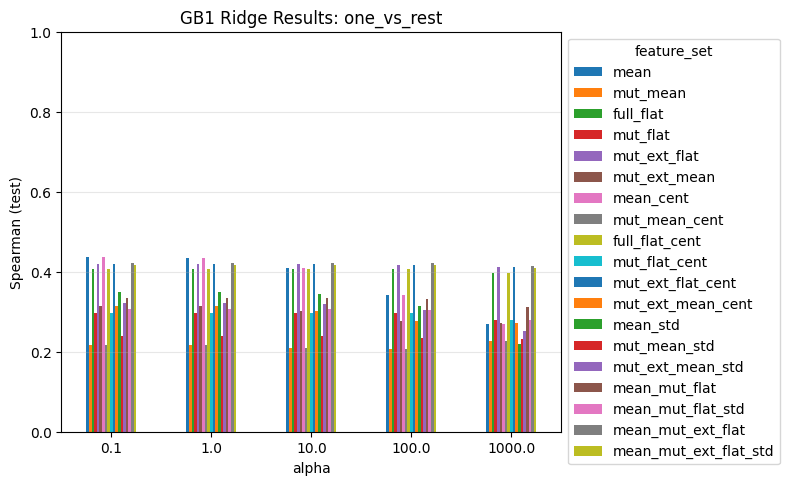

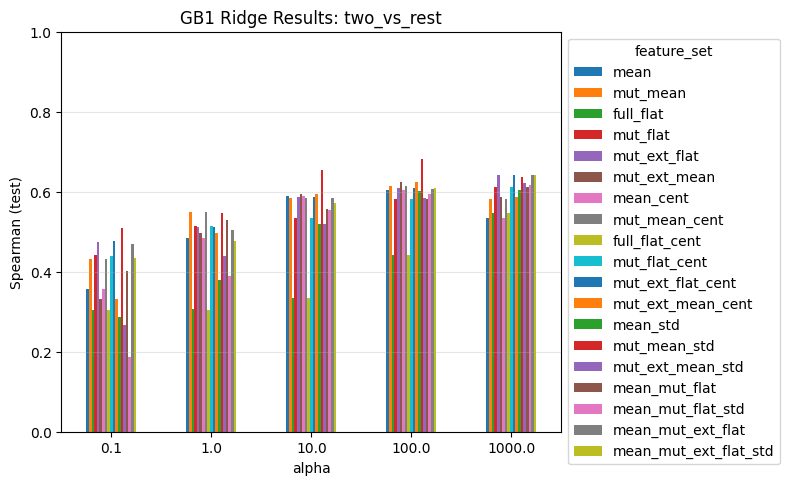

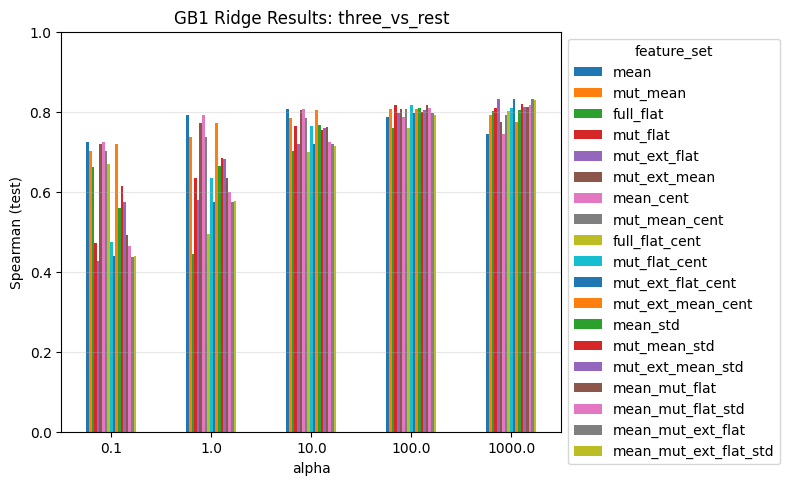

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# If alpha is in the index, move it into a column
plot_df = results_df.reset_index().rename(columns={"index": "alpha"}).copy()
plot_df = plot_df.rename(columns={'level_0': 'alpha', 'level_1': 'exp_id'})

# If the alpha column got a different name after reset_index, rename it here if needed
# print(plot_df.columns)

# Enforce ordering
split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
feature_order = ["mean", "mut_mean", "full_flat", "mut_flat", "mut_ext_flat", 'mut_ext_mean',
                  "mean_cent", "mut_mean_cent", "full_flat_cent", "mut_flat_cent", "mut_ext_flat_cent",
                  'mut_ext_mean_cent', "mean_std", "mut_mean_std", "mut_ext_mean_std", "mean_mut_flat",
                  "mean_mut_flat_std",  "mean_mut_ext_flat", "mean_mut_ext_flat_std"]

plot_df["split"] = pd.Categorical(plot_df["split"], categories=split_order, ordered=True)
plot_df["feature_set"] = pd.Categorical(plot_df["feature_set"], categories=feature_order, ordered=True)

# Make sure alpha is sorted nicely
plot_df = plot_df.sort_values(["split", "alpha", "feature_set"]).copy()

for split_name in split_order:
    subdf = plot_df[plot_df["split"] == split_name].copy()

    # Pivot so rows = alpha, columns = feature_set, values = spearman
    pivot_df = subdf.pivot(index="alpha", columns="feature_set", values="spearman")

    ax = pivot_df[feature_order].plot(
        kind="bar",
        figsize=(8, 5),
        rot=0
    )

    ax.set_title(f"GB1 Ridge Results: {split_name}")
    ax.set_xlabel("alpha")
    ax.set_ylabel("Spearman (test)")
    ax.legend(title="feature_set", loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_19090/821612882.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["feature_set", "split"], as_index=False)["spearman"]


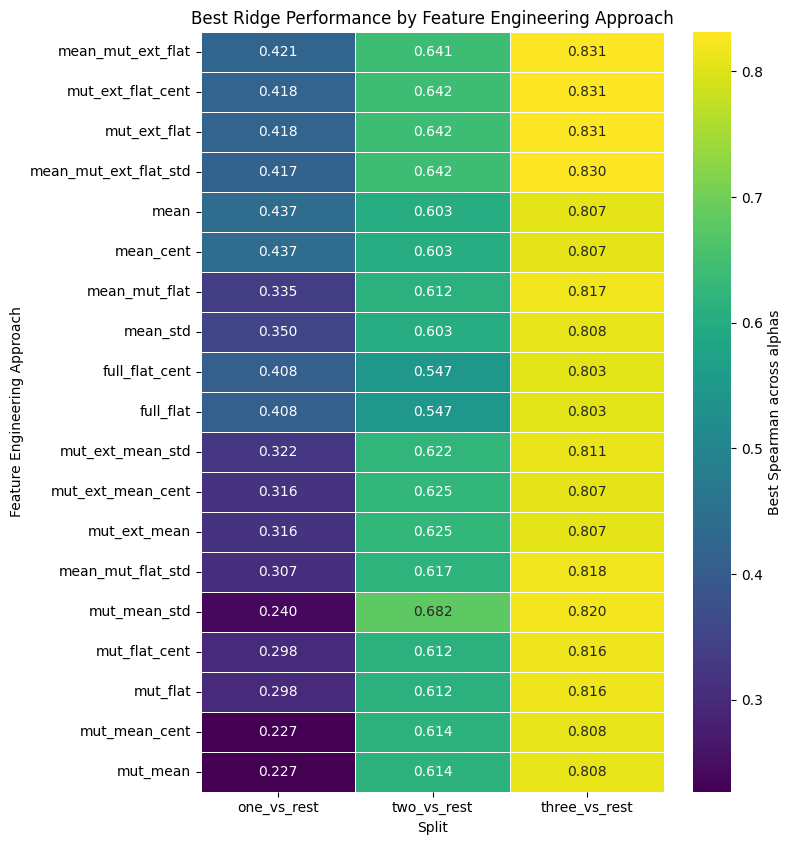

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Clean up alpha column name if needed
# -----------------------------
plot_df = results_df.reset_index().rename(columns={"index": "alpha"}).copy()
plot_df = plot_df.rename(columns={'level_0': 'alpha', 'level_1': 'exp_id'})

# optional: make sure alpha is numeric
plot_df["alpha"] = pd.to_numeric(plot_df["alpha"], errors="coerce")

# -----------------------------
# 2. Take best Spearman across alpha
# -----------------------------
best_df = (
    plot_df
    .groupby(["feature_set", "split"], as_index=False)["spearman"]
    .max()
)

# -----------------------------
# 3. Pivot into heatmap format
# -----------------------------
split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

heatmap_df = (
    best_df
    .pivot(index="feature_set", columns="split", values="spearman")
    .reindex(columns=split_order)
)

# optional: order rows by average performance across splits
row_order = heatmap_df.mean(axis=1).sort_values(ascending=False).index
heatmap_df = heatmap_df.loc[row_order]

# -----------------------------
# 4. Plot heatmap
# -----------------------------
plt.figure(figsize=(8, max(6, 0.45 * len(heatmap_df))))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Best Spearman across alphas"}
)

ax.set_title("Best Ridge Performance by Feature Engineering Approach")
ax.set_xlabel("Split")
ax.set_ylabel("Feature Engineering Approach")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

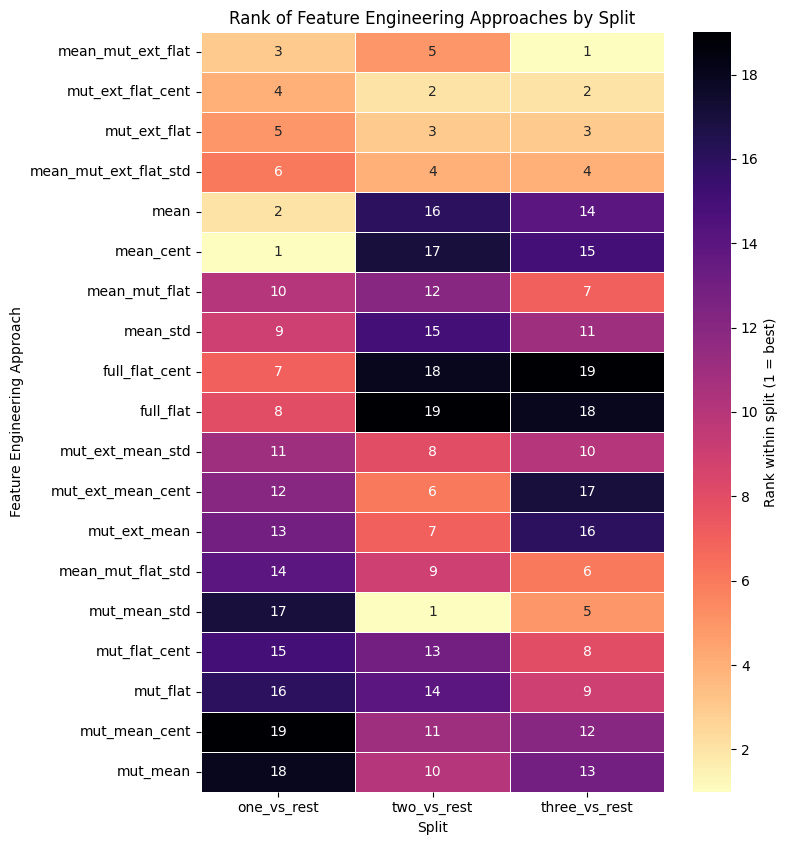

In [ ]:
# -----------------------------
# 5. Rank heatmap within each split
# rank 1 = best
# -----------------------------
rank_df = heatmap_df.rank(axis=0, ascending=False, method="min")

plt.figure(figsize=(8, max(6, 0.45 * len(rank_df))))
ax = sns.heatmap(
    rank_df,
    annot=True,
    fmt=".0f",
    cmap="magma_r",
    linewidths=0.5,
    cbar_kws={"label": "Rank within split (1 = best)"}
)

ax.set_title("Rank of Feature Engineering Approaches by Split")
ax.set_xlabel("Split")
ax.set_ylabel("Feature Engineering Approach")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

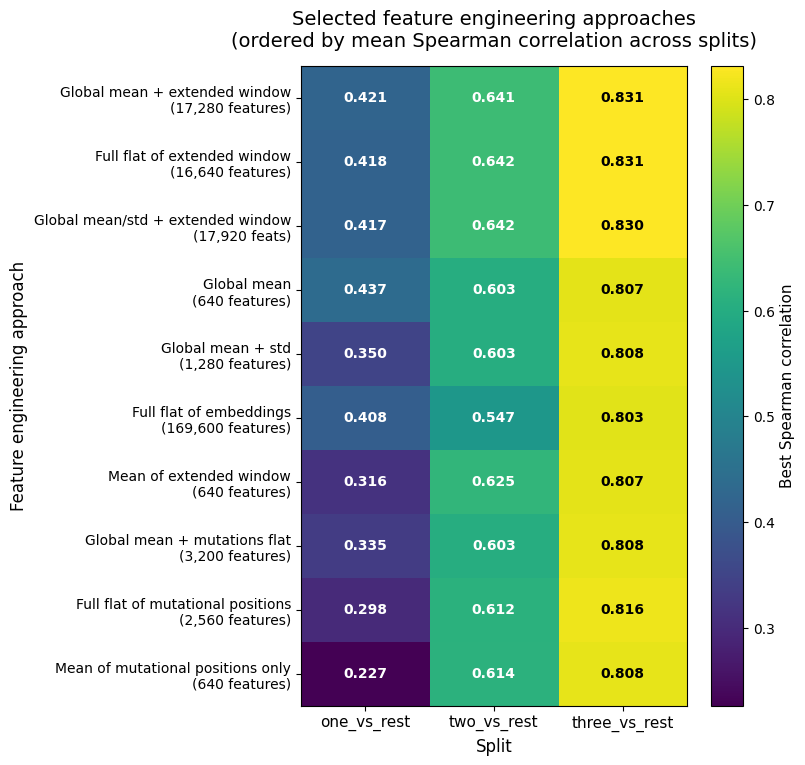

                            approach         dim_label  mean_across_splits  \
0      Global mean + extended window   17,280 features               0.631   
1       Full flat of extended window   16,640 features               0.630   
2  Global mean/std + extended window      17,920 feats               0.630   
3                        Global mean      640 features               0.616   
4                  Global mean + std    1,280 features               0.587   
5            Full flat of embeddings  169,600 features               0.586   
6            Mean of extended window      640 features               0.583   
7       Global mean + mutations flat    3,200 features               0.582   
8  Full flat of mutational positions    2,560 features               0.575   
9  Mean of mutational positions only      640 features               0.550   

   one_vs_rest  two_vs_rest  three_vs_rest  
0        0.421        0.641          0.831  
1        0.418        0.642          0.831  
2     

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Figure 2: Selected feature engineering approaches
# Ordered by mean performance across splits
# ------------------------------------------------------------

rows = [
    {
        "approach": "Full flat of embeddings",
        "dim_label": "169,600 features",
        "one_vs_rest": 0.408,
        "two_vs_rest": 0.547,
        "three_vs_rest": 0.803,
    },
    {
        "approach": "Global mean",
        "dim_label": "640 features",
        "one_vs_rest": 0.437,
        "two_vs_rest": 0.603,
        "three_vs_rest": 0.807,
    },
    {
        "approach": "Global mean + std",
        "dim_label": "1,280 features",
        "one_vs_rest": 0.350,
        "two_vs_rest": 0.603,
        "three_vs_rest": 0.808,
    },
    {
        "approach": "Full flat of mutational positions",
        "dim_label": "2,560 features",
        "one_vs_rest": 0.298,
        "two_vs_rest": 0.612,
        "three_vs_rest": 0.816,
    },
    {
        "approach": "Mean of mutational positions only",
        "dim_label": "640 features",
        "one_vs_rest": 0.227,
        "two_vs_rest": 0.614,
        "three_vs_rest": 0.808,
    },
    {
        "approach": "Full flat of extended window",
        "dim_label": "16,640 features",
        "one_vs_rest": 0.418,
        "two_vs_rest": 0.642,
        "three_vs_rest": 0.831,
    },
    {
        "approach": "Mean of extended window",
        "dim_label": "640 features",
        "one_vs_rest": 0.316,
        "two_vs_rest": 0.625,
        "three_vs_rest": 0.807,
    },
    {
        "approach": "Global mean + mutations flat",
        "dim_label": "3,200 features",
        "one_vs_rest": 0.335,
        "two_vs_rest": 0.603,
        "three_vs_rest": 0.808,
    },
    {
        "approach": "Global mean + extended window",
        "dim_label": "17,280 features",
        "one_vs_rest": 0.421,
        "two_vs_rest": 0.641,
        "three_vs_rest": 0.831,
    },
    {
        "approach": "Global mean/std + extended window",
        "dim_label": "17,920 feats",
        "one_vs_rest": 0.417,
        "two_vs_rest": 0.642,
        "three_vs_rest": 0.830,
    },
]

df = pd.DataFrame(rows)

# Compute mean across splits and sort descending
split_cols = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
df["mean_across_splits"] = df[split_cols].mean(axis=1)
df = df.sort_values("mean_across_splits", ascending=False).reset_index(drop=True)

# Row labels with dimensions
df["row_label"] = (
    df["approach"] + "\n" +
    "(" + df["dim_label"] + ")"
)

plot_df = df[split_cols].copy()
row_labels = df["row_label"].tolist()

# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.5, 7.8))

im = ax.imshow(plot_df.values, aspect="auto", cmap="viridis")

# Ticks / labels
ax.set_xticks(np.arange(len(split_cols)))
ax.set_xticklabels(["one_vs_rest", "two_vs_rest", "three_vs_rest"], fontsize=11)

ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)

ax.set_xlabel("Split", fontsize=12)
ax.set_ylabel("Feature engineering approach", fontsize=12)
ax.set_title(
    "Selected feature engineering approaches\n"
    "(ordered by mean Spearman correlation across splits)",
    fontsize=14,
    pad=14
)

# Annotate cells with values
for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        val = plot_df.iloc[i, j]
        ax.text(
            j, i, f"{val:.3f}",
            ha="center",
            va="center",
            color="white" if val < 0.68 else "black",
            fontsize=10,
            fontweight="bold"
        )

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Best Spearman correlation", fontsize=11)

# Improve spacing for long y-axis labels
plt.tight_layout()
plt.subplots_adjust(left=0.46, right=0.92, top=0.90, bottom=0.08)

# Save if desired
# plt.savefig("figure2_selected_feature_engineering_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

# Optional: print the ordered table used for plotting
display_cols = ["approach", "dim_label", "mean_across_splits"] + split_cols
print(df[display_cols].round(3))

## Data engineering window refinement

In [ ]:
import numpy as np
import pandas as pd

mut_positions = [38, 39, 40, 53]
results_list = []

for alpha in [0.1, 1, 10, 100, 1000]:
    res_k_list = []

    for k in range(0, 10):
        # build window positions fresh for this k
        mut_positions_ext = set(mut_positions)

        # add k residues on each side of each mutation position
        for pos in mut_positions:
            for offset in range(1, k + 1):
                if pos - offset >= 0:
                    mut_positions_ext.add(pos - offset)
                if pos + offset < X_full_residue.shape[1]:
                    mut_positions_ext.add(pos + offset)

        mut_positions_ext = sorted(mut_positions_ext)

        # slice + flatten
        X_mut_ext_k = X_full_residue[:, mut_positions_ext, :]
        X_mut_ext_k_flat = X_mut_ext_k.reshape(X_mut_ext_k.shape[0], -1)

        # concatenate with full-sequence mean
        X_mean_mut_ext_k_flat = np.concatenate((X_mean, X_mut_ext_k_flat), axis=1)

        print(f"alpha={alpha}, k={k}, shape={X_mean_mut_ext_k_flat.shape}")

        # evaluate and store
        res_k = evaluate_feature_set(
            f"mean_mut_window_k{k}",
            X_mean_mut_ext_k_flat,
            df_full,
            alpha=alpha
        )
        res_k_list.append(res_k)

    # combine all k results for this alpha
    results_df = pd.concat(res_k_list, ignore_index=True)

    # ordering
    results_df["split"] = pd.Categorical(
        results_df["split"],
        categories=["one_vs_rest", "two_vs_rest", "three_vs_rest"],
        ordered=True,
    )

    results_df["feature_set"] = pd.Categorical(
        results_df["feature_set"],
        categories=[f"mean_mut_window_k{k}" for k in range(0, 10)],
        ordered=True,
    )

    results_df = results_df.sort_values(["feature_set", "split"]).reset_index(drop=True)

    results_list.append(results_df)
    print(f"finished alpha={alpha}")

alpha=0.1, k=0, shape=(8733, 3200)
alpha=0.1, k=1, shape=(8733, 5760)
alpha=0.1, k=2, shape=(8733, 8320)
alpha=0.1, k=3, shape=(8733, 10880)
alpha=0.1, k=4, shape=(8733, 13440)
alpha=0.1, k=5, shape=(8733, 16000)
alpha=0.1, k=6, shape=(8733, 18560)
alpha=0.1, k=7, shape=(8733, 19840)
alpha=0.1, k=8, shape=(8733, 21120)
alpha=0.1, k=9, shape=(8733, 22400)
finished alpha=0.1
alpha=1, k=0, shape=(8733, 3200)
alpha=1, k=1, shape=(8733, 5760)
alpha=1, k=2, shape=(8733, 8320)
alpha=1, k=3, shape=(8733, 10880)
alpha=1, k=4, shape=(8733, 13440)
alpha=1, k=5, shape=(8733, 16000)
alpha=1, k=6, shape=(8733, 18560)
alpha=1, k=7, shape=(8733, 19840)
alpha=1, k=8, shape=(8733, 21120)
alpha=1, k=9, shape=(8733, 22400)
finished alpha=1
alpha=10, k=0, shape=(8733, 3200)
alpha=10, k=1, shape=(8733, 5760)
alpha=10, k=2, shape=(8733, 8320)
alpha=10, k=3, shape=(8733, 10880)
alpha=10, k=4, shape=(8733, 13440)
alpha=10, k=5, shape=(8733, 16000)
alpha=10, k=6, shape=(8733, 18560)
alpha=10, k=7, shape=(8733, 

In [ ]:
final_results_df = pd.concat(results_list, keys=[0.1, 1, 10, 100, 1000]).reset_index()
final_results_df = final_results_df.rename(columns={"level_0": "alpha"})

In [ ]:
final_results_df[final_results_df['split']=='one_vs_rest'].sort_values(by='spearman', ascending=False).head(20)

,alpha,level_1,n_train,n_test,spearman,feature_set,split
21,0.1,21,28,8705,0.418093,mean_mut_window_k7,one_vs_rest
51,1.0,21,28,8705,0.418087,mean_mut_window_k7,one_vs_rest
81,10.0,21,28,8705,0.418046,mean_mut_window_k7,one_vs_rest
111,100.0,21,28,8705,0.417527,mean_mut_window_k7,one_vs_rest
15,0.1,15,28,8705,0.415626,mean_mut_window_k5,one_vs_rest
45,1.0,15,28,8705,0.415625,mean_mut_window_k5,one_vs_rest
75,10.0,15,28,8705,0.415576,mean_mut_window_k5,one_vs_rest
18,0.1,18,28,8705,0.415556,mean_mut_window_k6,one_vs_rest
48,1.0,18,28,8705,0.415554,mean_mut_window_k6,one_vs_rest
78,10.0,18,28,8705,0.415512,mean_mut_window_k6,one_vs_rest


In [ ]:
final_results_df[final_results_df['split']=='two_vs_rest'].sort_values(by='spearman', ascending=False).head(20)

,alpha,level_1,n_train,n_test,spearman,feature_set,split
136,1000.0,16,424,8309,0.642041,mean_mut_window_k5,two_vs_rest
133,1000.0,13,424,8309,0.641808,mean_mut_window_k4,two_vs_rest
139,1000.0,19,424,8309,0.640878,mean_mut_window_k6,two_vs_rest
142,1000.0,22,424,8309,0.638447,mean_mut_window_k7,two_vs_rest
130,1000.0,10,424,8309,0.636689,mean_mut_window_k3,two_vs_rest
145,1000.0,25,424,8309,0.634274,mean_mut_window_k8,two_vs_rest
148,1000.0,28,424,8309,0.630544,mean_mut_window_k9,two_vs_rest
127,1000.0,7,424,8309,0.622008,mean_mut_window_k2,two_vs_rest
124,1000.0,4,424,8309,0.620495,mean_mut_window_k1,two_vs_rest
106,100.0,16,424,8309,0.619264,mean_mut_window_k5,two_vs_rest


In [ ]:
final_results_df[final_results_df['split']=='three_vs_rest'].sort_values(by='spearman', ascending=False).head(20)

,alpha,level_1,n_train,n_test,spearman,feature_set,split
134,1000.0,14,2990,5743,0.830981,mean_mut_window_k4,three_vs_rest
137,1000.0,17,2990,5743,0.830857,mean_mut_window_k5,three_vs_rest
140,1000.0,20,2990,5743,0.830590,mean_mut_window_k6,three_vs_rest
131,1000.0,11,2990,5743,0.830371,mean_mut_window_k3,three_vs_rest
128,1000.0,8,2990,5743,0.830047,mean_mut_window_k2,three_vs_rest
146,1000.0,26,2990,5743,0.829894,mean_mut_window_k8,three_vs_rest
143,1000.0,23,2990,5743,0.829781,mean_mut_window_k7,three_vs_rest
149,1000.0,29,2990,5743,0.828381,mean_mut_window_k9,three_vs_rest
125,1000.0,5,2990,5743,0.827850,mean_mut_window_k1,three_vs_rest
95,100.0,5,2990,5743,0.818046,mean_mut_window_k1,three_vs_rest


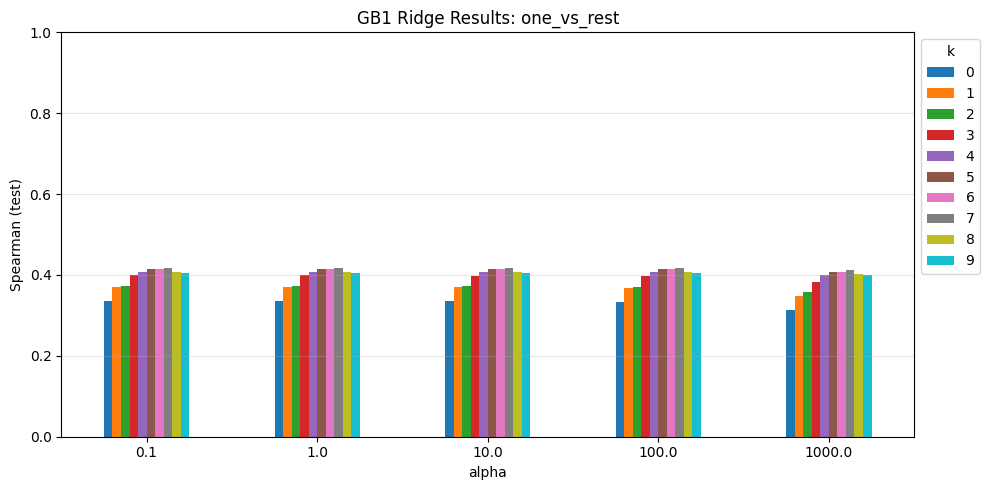

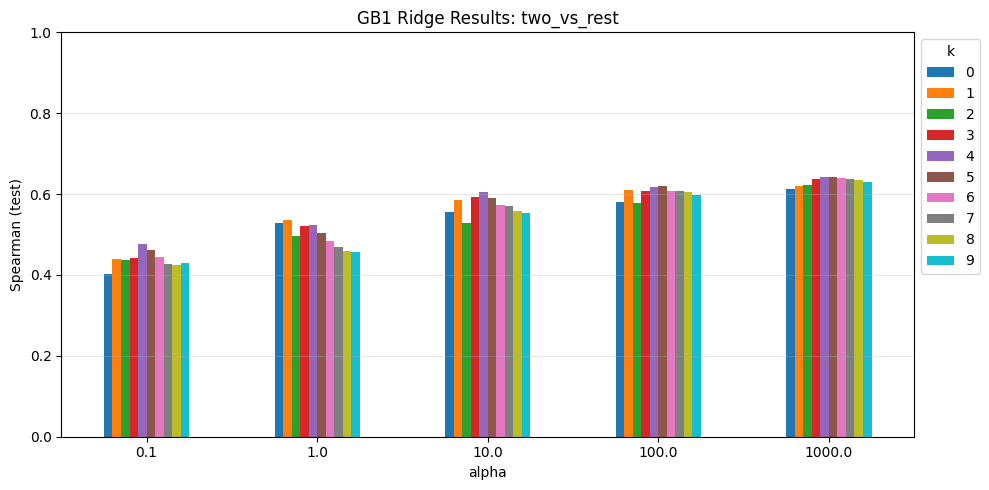

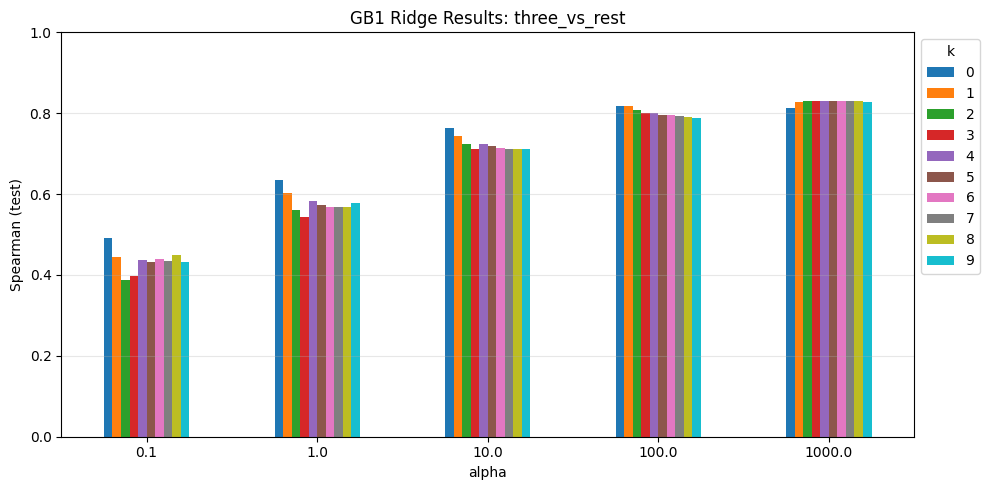

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plot_df = final_results_df.copy()

# -----------------------------
# Clean up / recover k if needed
# -----------------------------
if "k" not in plot_df.columns:
    plot_df["k"] = (
        plot_df["feature_set"]
        .astype(str)
        .str.extract(r'k(\d+)')[0]
        .astype(int)
    )

# make sure alpha numeric
plot_df["alpha"] = pd.to_numeric(plot_df["alpha"], errors="coerce")

# ordering
split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
k_order = sorted(plot_df["k"].dropna().unique())

plot_df["split"] = pd.Categorical(plot_df["split"], categories=split_order, ordered=True)
plot_df["k"] = pd.Categorical(plot_df["k"], categories=k_order, ordered=True)

plot_df = plot_df.sort_values(["split", "alpha", "k"]).copy()

# -----------------------------
# Plot one chart per split
# -----------------------------
for split_name in split_order:
    subdf = plot_df[plot_df["split"] == split_name].copy()

    pivot_df = subdf.pivot(index="alpha", columns="k", values="spearman")

    ax = pivot_df[k_order].plot(
        kind="bar",
        figsize=(10, 5),
        rot=0
    )

    ax.set_title(f"GB1 Ridge Results: {split_name}")
    ax.set_xlabel("alpha")
    ax.set_ylabel("Spearman (test)")
    ax.legend(title="k", loc="upper left", bbox_to_anchor=(1, 1))
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_19090/575253945.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["k", "split"], as_index=False)["spearman"]


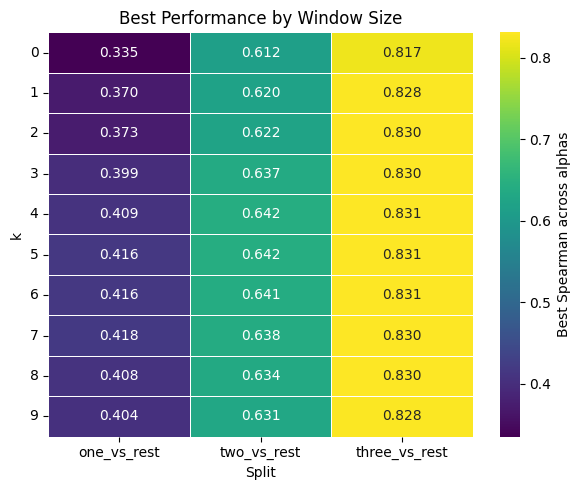

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = final_results_df.copy()

if "k" not in plot_df.columns:
    plot_df["k"] = (
        plot_df["feature_set"]
        .astype(str)
        .str.extract(r'k(\d+)')[0]
        .astype(int)
    )

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
k_order = sorted(plot_df["k"].dropna().unique())

# best over alpha
best_df = (
    plot_df
    .groupby(["k", "split"], as_index=False)["spearman"]
    .max()
)

heatmap_df = (
    best_df
    .pivot(index="k", columns="split", values="spearman")
    .reindex(index=k_order, columns=split_order)
)

plt.figure(figsize=(6, max(4, 0.5 * len(heatmap_df))))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Best Spearman across alphas"}
)

ax.set_title("Best Performance by Window Size")
ax.set_xlabel("Split")
ax.set_ylabel("k")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

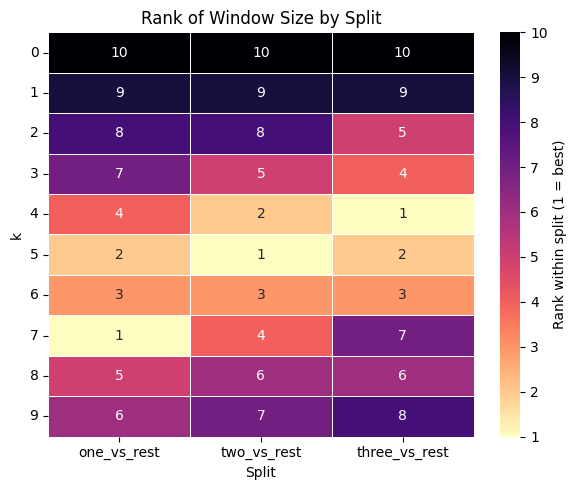

In [ ]:
rank_df = heatmap_df.rank(axis=0, ascending=False, method="min")

plt.figure(figsize=(6, max(4, 0.5 * len(rank_df))))
ax = sns.heatmap(
    rank_df,
    annot=True,
    fmt=".0f",
    cmap="magma_r",
    linewidths=0.5,
    cbar_kws={"label": "Rank within split (1 = best)"}
)

ax.set_title("Rank of Window Size by Split")
ax.set_xlabel("Split")
ax.set_ylabel("k")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

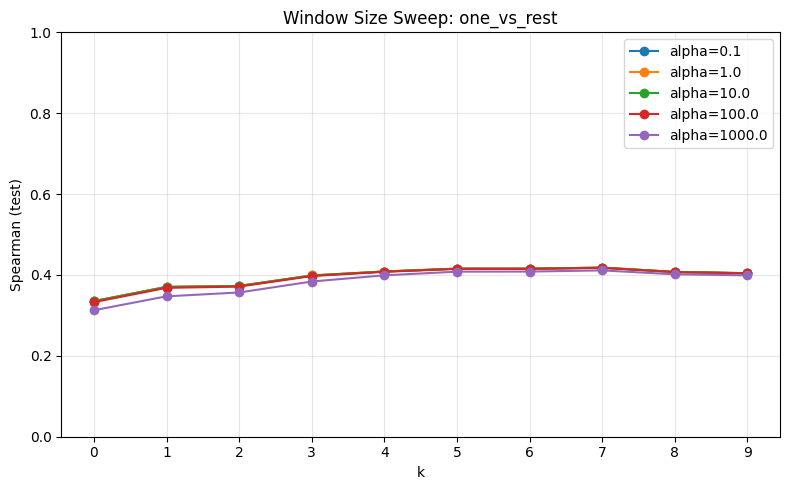

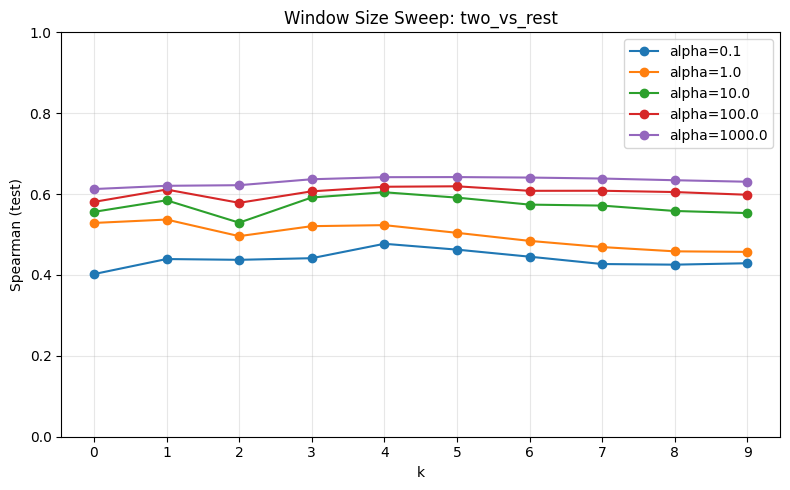

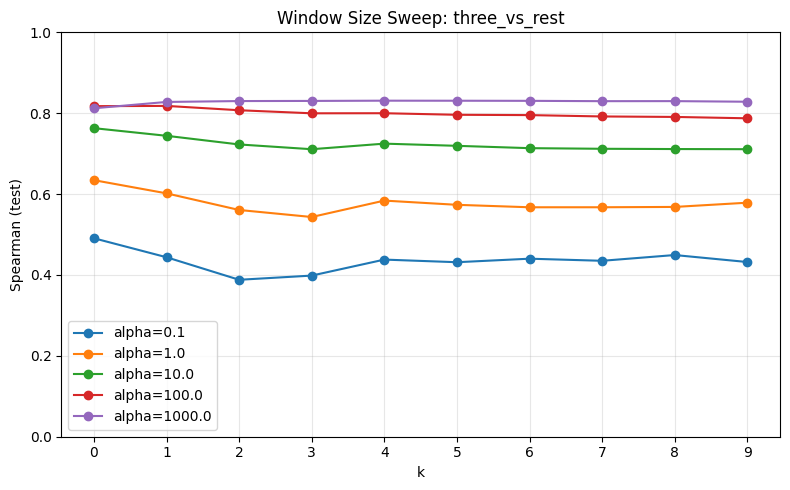

In [ ]:
import matplotlib.pyplot as plt

plot_df = final_results_df.copy()

if "k" not in plot_df.columns:
    plot_df["k"] = (
        plot_df["feature_set"]
        .astype(str)
        .str.extract(r'k(\d+)')[0]
        .astype(int)
    )

plot_df["alpha"] = pd.to_numeric(plot_df["alpha"], errors="coerce")

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
alpha_order = sorted(plot_df["alpha"].dropna().unique())
k_order = sorted(plot_df["k"].dropna().unique())

for split_name in split_order:
    subdf = plot_df[plot_df["split"] == split_name].copy()

    plt.figure(figsize=(8, 5))
    for alpha in alpha_order:
        alpha_df = subdf[subdf["alpha"] == alpha].sort_values("k")
        plt.plot(alpha_df["k"], alpha_df["spearman"], marker="o", label=f"alpha={alpha}")

    plt.title(f"Window Size Sweep: {split_name}")
    plt.xlabel("k")
    plt.ylabel("Spearman (test)")
    plt.ylim(0, 1)
    plt.xticks(k_order)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Lit results and plots

In [ ]:
lit_results = pd.DataFrame({
    "model": [
        "ESM1v_perAA",
        "ESM1v_mean",
        "ESM1v_mutmean",
        "ESM2_attention",
        "Ridge",
        "MLP"
    ],
    "one_vs_rest": [0.28, 0.32, 0.19, 0, 0.416, 0.343],
    "two_vs_rest": [0.28, 0.32, 0.19, 0.635, 0.642, 0.772],
    "three_vs_rest": [0.82, 0.77, 0.80, 0.85, 0.831, 0.875]
})

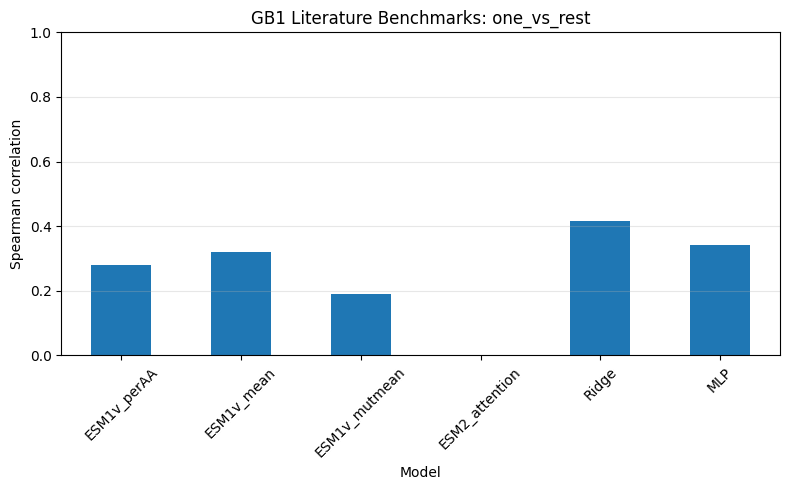

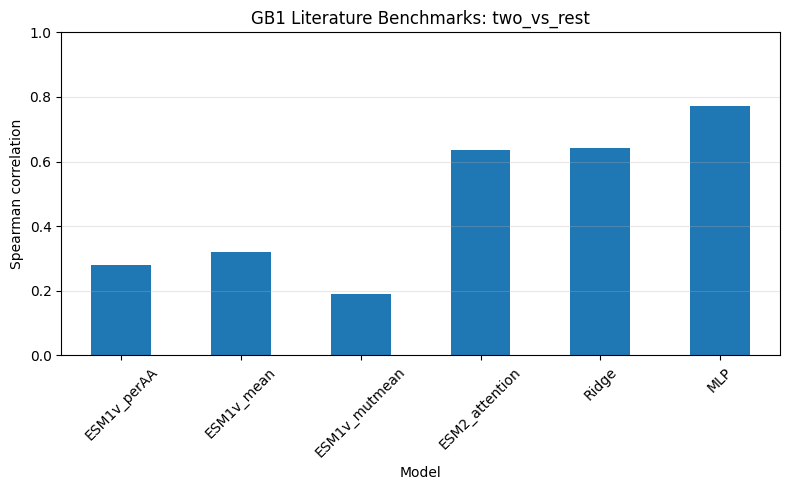

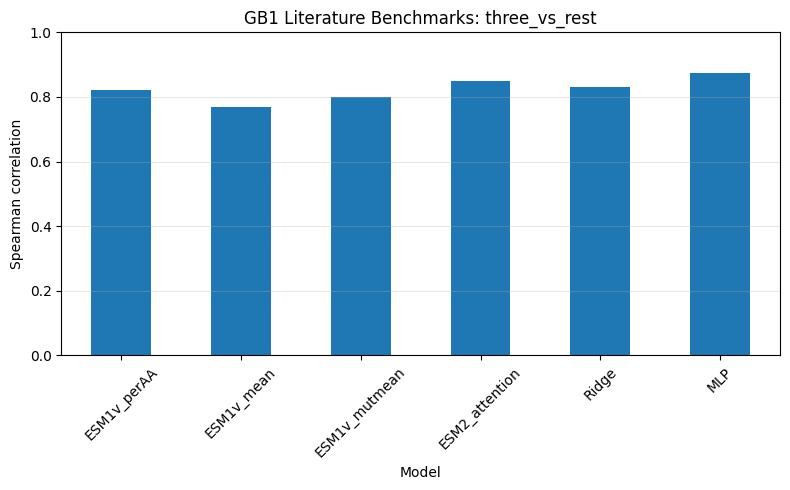

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

for split in split_order:

    # set model names as index
    plot_df = lit_results.set_index("model")[split]

    fig, ax = plt.subplots(figsize=(8,5))

    plot_df.plot(
        kind="bar",
        ax=ax,
        rot=45
    )

    ax.set_title(f"GB1 Literature Benchmarks: {split}")
    ax.set_ylabel("Spearman correlation")
    ax.set_xlabel("Model")
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

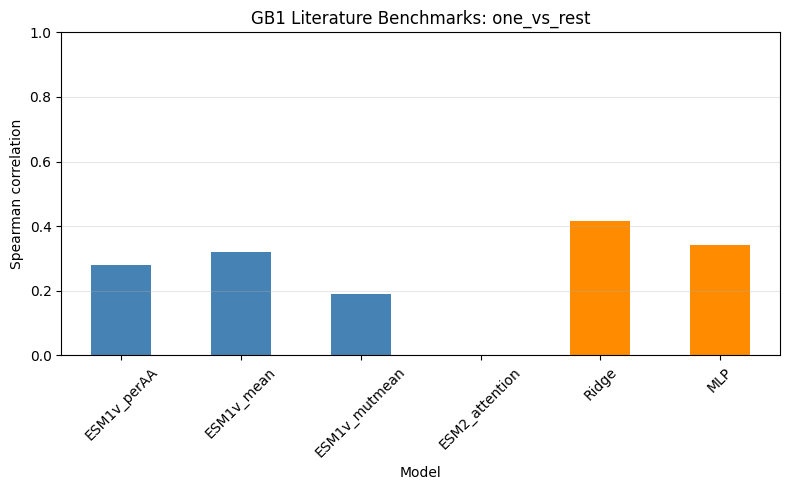

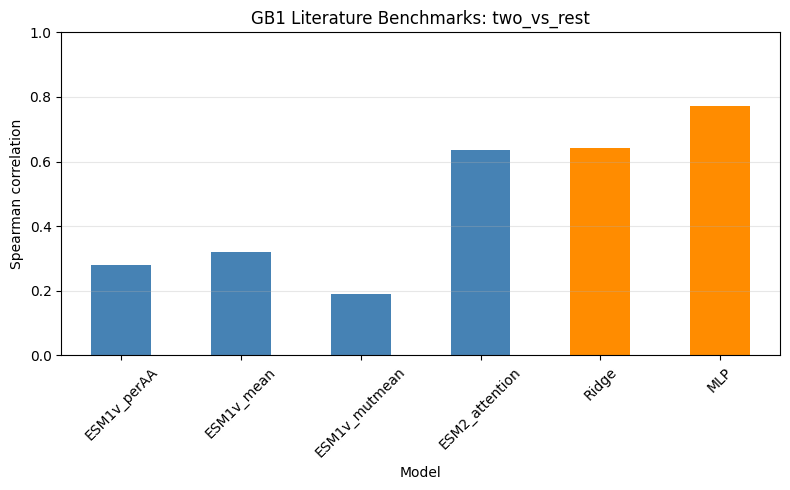

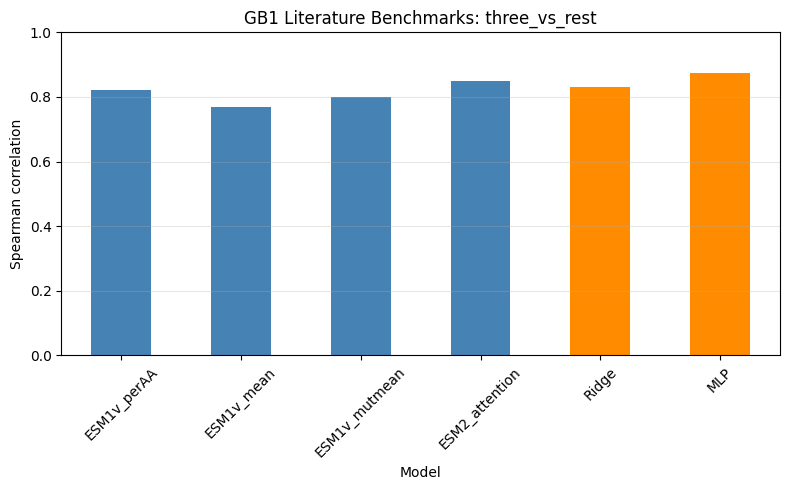

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

lit_results = pd.DataFrame({
    "model": [
        "ESM1v_perAA",
        "ESM1v_mean",
        "ESM1v_mutmean",
        "ESM2_attention",
        "Ridge",
        "MLP"
    ],
    "one_vs_rest": [0.28, 0.32, 0.19, 0, 0.416, 0.343],
    "two_vs_rest": [0.28, 0.32, 0.19, 0.635, 0.642, 0.772],
    "three_vs_rest": [0.82, 0.77, 0.80, 0.85, 0.831, 0.875]
})

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

# color your own models differently
highlight_models = {"Ridge", "MLP"}
base_color = "steelblue"
highlight_color = "darkorange"

for split in split_order:
    plot_df = lit_results.set_index("model")[split]

    colors = [
        highlight_color if model in highlight_models else base_color
        for model in plot_df.index
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    plot_df.plot(
        kind="bar",
        ax=ax,
        rot=45,
        color=colors
    )

    ax.set_title(f"GB1 Literature Benchmarks: {split}")
    ax.set_ylabel("Spearman correlation")
    ax.set_xlabel("Model")
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

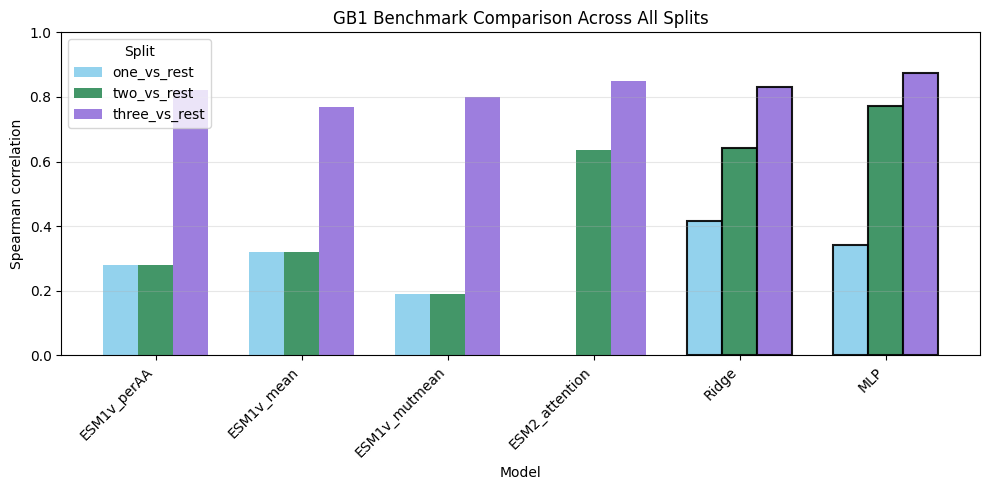

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

lit_results = pd.DataFrame({
    "model": [
        "ESM1v_perAA",
        "ESM1v_mean",
        "ESM1v_mutmean",
        "ESM2_attention",
        "Ridge",
        "MLP"
    ],
    "one_vs_rest": [0.28, 0.32, 0.19, 0, 0.416, 0.343],
    "two_vs_rest": [0.28, 0.32, 0.19, 0.635, 0.642, 0.772],
    "three_vs_rest": [0.82, 0.77, 0.80, 0.85, 0.831, 0.875]
})

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
models = lit_results["model"].tolist()

x = np.arange(len(models))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5))

split_colors = {
    "one_vs_rest": "skyblue",
    "two_vs_rest": "seagreen",
    "three_vs_rest": "mediumpurple"
}

# make Ridge/MLP slightly more opaque / edged for emphasis
highlight_models = {"Ridge", "MLP"}

for i, split in enumerate(split_order):
    values = lit_results[split].values
    bars = ax.bar(
        x + (i - 1) * width,
        values,
        width=width,
        label=split,
        color=split_colors[split],
        alpha=0.9
    )

    for j, bar in enumerate(bars):
        if models[j] in highlight_models:
            bar.set_edgecolor("black")
            bar.set_linewidth(1.5)

ax.set_title("GB1 Benchmark Comparison Across All Splits")
ax.set_ylabel("Spearman correlation")
ax.set_xlabel("Model")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Split")

plt.tight_layout()
plt.show()

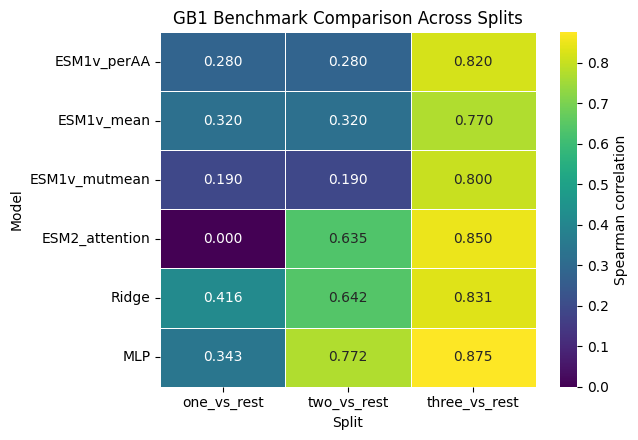

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

lit_results = pd.DataFrame({
    "model": [
        "ESM1v_perAA",
        "ESM1v_mean",
        "ESM1v_mutmean",
        "ESM2_attention",
        "Ridge",
        "MLP"
    ],
    "one_vs_rest": [0.28, 0.32, 0.19, 0, 0.416, 0.343],
    "two_vs_rest": [0.28, 0.32, 0.19, 0.635, 0.642, 0.772],
    "three_vs_rest": [0.82, 0.77, 0.80, 0.85, 0.831, 0.875]
})

heatmap_df = lit_results.set_index("model")

plt.figure(figsize=(6.5, 4.5))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"}
)

ax.set_title("GB1 Benchmark Comparison Across Splits")
ax.set_xlabel("Split")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

## Model Selection

In [ ]:
import numpy as np
import torch

def get_window_positions(mut_positions, seq_len, k=5):
    """
    Build sorted unique residue positions consisting of each mutation position
    plus +/- k residues around each mutation position.
    """
    pos_set = set(mut_positions)
    for pos in mut_positions:
        for offset in range(1, k + 1):
            if pos - offset >= 0:
                pos_set.add(pos - offset)
            if pos + offset < seq_len:
                pos_set.add(pos + offset)
    return sorted(pos_set)


def build_gb1_features_torch(
    X_full_residue,
    mut_positions,
    k=5,
    include_mean=True,
    include_std=False,
    include_window_flat=True,
    return_window_tensor=False,
    as_torch=True,
    dtype=torch.float32,
):
    """
    Build feature matrix for GB1 from residue-level embeddings.

    Parameters
    ----------
    X_full_residue : np.ndarray or torch.Tensor
        Shape (n_samples, seq_len, emb_dim)
    mut_positions : list[int]
        Mutation positions in python indexing
    k : int
        Window radius around each mutation position
    include_mean : bool
        Include mean over full sequence
    include_std : bool
        Include std over full sequence
    include_window_flat : bool
        Include flattened local window embeddings
    return_window_tensor : bool
        If True, also return unflattened local window tensor
        shape = (n_samples, n_window_positions, emb_dim)
    as_torch : bool
        If True, return torch tensors
    dtype : torch dtype
        Tensor dtype when as_torch=True

    Returns
    -------
    X : np.ndarray or torch.Tensor
        Final feature matrix, shape (n_samples, n_features)
    feature_info : dict
    X_window : optional
        Returned only if return_window_tensor=True
    """
    # convert to numpy for feature construction
    if torch.is_tensor(X_full_residue):
        X_np = X_full_residue.detach().cpu().numpy()
    else:
        X_np = X_full_residue

    n_samples, seq_len, emb_dim = X_np.shape
    feature_blocks = []
    feature_names = []

    if include_mean:
        X_mean = X_np.mean(axis=1)
        feature_blocks.append(X_mean)
        feature_names.append("mean")

    if include_std:
        X_std = X_np.std(axis=1)
        feature_blocks.append(X_std)
        feature_names.append("std")

    window_positions = get_window_positions(mut_positions, seq_len, k=k)
    X_window = X_np[:, window_positions, :]   # (n_samples, n_window_pos, emb_dim)

    if include_window_flat:
        X_window_flat = X_window.reshape(n_samples, -1)
        feature_blocks.append(X_window_flat)
        feature_names.append("window_flat")

    if len(feature_blocks) == 0:
        raise ValueError("At least one feature block must be included.")

    X = np.concatenate(feature_blocks, axis=1)

    feature_info = {
        "k": k,
        "mut_positions": mut_positions,
        "window_positions": window_positions,
        "n_window_positions": len(window_positions),
        "emb_dim": emb_dim,
        "feature_blocks": feature_names,
        "n_features": X.shape[1],
    }

    if as_torch:
        X = torch.tensor(X, dtype=dtype)
        X_window = torch.tensor(X_window, dtype=dtype)

    if return_window_tensor:
        return X, feature_info, X_window
    else:
        return X, feature_info

In [ ]:
mut_positions = [38, 39, 40, 53]

X_k5, feature_info, X_window_k5 = build_gb1_features_torch(
    X_full_residue=X_full_residue,
    mut_positions=mut_positions,
    k=5,
    include_mean=True,
    include_std=False,
    include_window_flat=True,
    return_window_tensor=True,
    as_torch=True,
)

print("X_k5 shape:", X_k5.shape)
print("X_window_k5 shape:", X_window_k5.shape)
print(feature_info)

X_k5 shape: torch.Size([8733, 16000])
X_window_k5 shape: torch.Size([8733, 24, 640])
{'k': 5, 'mut_positions': [38, 39, 40, 53], 'window_positions': [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58], 'n_window_positions': 24, 'emb_dim': 640, 'feature_blocks': ['mean', 'window_flat'], 'n_features': 16000}


In [ ]:
def make_split_tensors(
    X,
    df,
    split_cols=("one_vs_rest", "two_vs_rest", "three_vs_rest"),
    target_col="Fitness",
    device="cpu",
    dtype=torch.float32,
):
    """
    Build train/test tensors for each split.

    Assumes df[split_name] contains 'train' and 'test'.
    """
    if not torch.is_tensor(X):
        X = torch.tensor(X, dtype=dtype)

    y = torch.tensor(df[target_col].values, dtype=dtype)

    split_data = {}

    for split_name in split_cols:
        train_mask = torch.tensor((df[split_name] == "train").values, dtype=torch.bool)
        test_mask = torch.tensor((df[split_name] == "test").values, dtype=torch.bool)

        split_data[split_name] = {
            "X_train": X[train_mask].to(device),
            "y_train": y[train_mask].to(device),
            "X_test": X[test_mask].to(device),
            "y_test": y[test_mask].to(device),
        }

    return split_data

In [ ]:
split_tensors = make_split_tensors(
    X=X_window_k5,
    df=df_full,
    target_col="fitness",
    device="cpu",   # change to "cuda" if using GPU
)

for split_name, d in split_tensors.items():
    print(split_name, d["X_train"].shape, d["X_test"].shape)

one_vs_rest torch.Size([28, 24, 640]) torch.Size([8705, 24, 640])
two_vs_rest torch.Size([424, 24, 640]) torch.Size([8309, 24, 640])
three_vs_rest torch.Size([2990, 24, 640]) torch.Size([5743, 24, 640])


In [ ]:
from torch.utils.data import Dataset, DataLoader

class TensorRegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
split_name = "one_vs_rest"
X_train = split_tensors[split_name]["X_train"]
y_train = split_tensors[split_name]["y_train"]
X_test = split_tensors[split_name]["X_test"]
y_test = split_tensors[split_name]["y_test"]

train_ds = TensorRegressionDataset(X_train, y_train)
test_ds = TensorRegressionDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [ ]:
import torch.nn as nn

class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dims=(512, 256), dropout=0.2):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [ ]:
input_dim = X_train.shape[1]
model = MLPRegressor(input_dim=input_dim, hidden_dims=(512, 256), dropout=0.2)

In [ ]:
from scipy.stats import spearmanr

def compute_spearman(y_true, y_pred):
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()
    return spearmanr(y_true_np, y_pred_np).statistic

In [ ]:
def train_torch_regressor(
    model,
    train_loader,
    test_loader,
    num_epochs=100,
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu",
    verbose=True,
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    history = []

    for epoch in range(num_epochs):
        # train
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # eval
        model.eval()
        test_losses = []
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)

                test_losses.append(loss.item())
                all_preds.append(pred)
                all_targets.append(yb)

        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        test_spearman = compute_spearman(all_targets, all_preds)

        epoch_info = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "test_loss": float(np.mean(test_losses)),
            "test_spearman": test_spearman,
        }
        history.append(epoch_info)

        if verbose and (epoch % 10 == 0 or epoch == num_epochs - 1):
            print(
                f"epoch {epoch:03d} | "
                f"train_loss={epoch_info['train_loss']:.4f} | "
                f"test_loss={epoch_info['test_loss']:.4f} | "
                f"test_spearman={epoch_info['test_spearman']:.4f}"
            )

    history_df = pd.DataFrame(history)
    return model, history_df

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# build features
mut_positions = [38, 39, 40, 53]
X_k5, feature_info, X_window_k5 = build_gb1_features_torch(
    X_full_residue=X_full_residue,
    mut_positions=mut_positions,
    k=5,
    include_mean=True,
    include_std=False,
    include_window_flat=True,
    return_window_tensor=True,
    as_torch=True,
)

# make splits
split_tensors = make_split_tensors(
    X=X_k5,
    df=df_full,
    target_col="fitness",
    device="cpu",
)

# choose split
split_name = "one_vs_rest"
X_train = split_tensors[split_name]["X_train"]
y_train = split_tensors[split_name]["y_train"]
X_test = split_tensors[split_name]["X_test"]
y_test = split_tensors[split_name]["y_test"]

# dataloaders
train_ds = TensorRegressionDataset(X_train, y_train)
test_ds = TensorRegressionDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

# model
model = MLPRegressor(
    input_dim=X_train.shape[1],
    hidden_dims=(512, 256),
    dropout=0.2,
)

# train
model, history_df = train_torch_regressor(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=100,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
    verbose=True,
)

history_df.tail()

epoch 000 | train_loss=3.3321 | test_loss=8.1130 | test_spearman=0.3057
epoch 010 | train_loss=0.8650 | test_loss=1.4594 | test_spearman=0.2962
epoch 020 | train_loss=0.7300 | test_loss=1.4983 | test_spearman=0.2148
epoch 030 | train_loss=0.7054 | test_loss=1.5074 | test_spearman=0.1749
epoch 040 | train_loss=0.5705 | test_loss=1.5892 | test_spearman=0.1741
epoch 050 | train_loss=0.4502 | test_loss=1.7431 | test_spearman=0.1916
epoch 060 | train_loss=0.3075 | test_loss=1.6657 | test_spearman=0.2301
epoch 070 | train_loss=0.1842 | test_loss=1.8527 | test_spearman=0.2696
epoch 080 | train_loss=0.1195 | test_loss=2.1030 | test_spearman=0.3018
epoch 090 | train_loss=0.0560 | test_loss=2.3224 | test_spearman=0.3202
epoch 099 | train_loss=0.1033 | test_loss=2.6774 | test_spearman=0.3354


,epoch,train_loss,test_loss,test_spearman
95,95,0.078648,2.378951,0.328239
96,96,0.098705,2.039161,0.331090
97,97,0.083329,2.085811,0.332462
98,98,0.134582,2.568347,0.333584
99,99,0.103291,2.677376,0.335443


In [ ]:
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# -----------------------------
# build features
# -----------------------------
mut_positions = [38, 39, 40, 53]
X_k5, feature_info, X_window_k5 = build_gb1_features_torch(
    X_full_residue=X_full_residue,
    mut_positions=mut_positions,
    k=5,
    include_mean=True,
    include_std=False,
    include_window_flat=True,
    return_window_tensor=True,
    as_torch=True,
)

print("feature_info:", feature_info)
print("X_k5 shape:", X_k5.shape)

# -----------------------------
# make splits
# -----------------------------
split_tensors = make_split_tensors(
    X=X_k5,
    df=df_full,
    target_col="fitness",
    device="cpu",   # keep master tensors on CPU; batches move to GPU in training loop
)

# -----------------------------
# hyperparameter sweep
# -----------------------------
results = []

for split_name in ["one_vs_rest", "two_vs_rest", "three_vs_rest"]:
    X_train = split_tensors[split_name]["X_train"]
    y_train = split_tensors[split_name]["y_train"]
    X_test = split_tensors[split_name]["X_test"]
    y_test = split_tensors[split_name]["y_test"]

    for train_batch_size in [32, 128]:
        train_ds = TensorRegressionDataset(X_train, y_train)
        test_ds = TensorRegressionDataset(X_test, y_test)

        train_loader = DataLoader(train_ds, batch_size=train_batch_size, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

        for hidden_dims in [(512, 256), (128, 64)]:
            for dropout in [0.2, 0.5]:
                for lr in [1e-3, 1e-4]:
                    for weight_decay in [1e-4, 1e-5]:
                        set_seed(42)

                        print(
                            f"split={split_name} | batch_size={train_batch_size} | "
                            f"hidden_dims={hidden_dims} | dropout={dropout} | "
                            f"lr={lr} | weight_decay={weight_decay}"
                        )

                        model = MLPRegressor(
                            input_dim=X_train.shape[1],
                            hidden_dims=hidden_dims,
                            dropout=dropout,
                        )

                        model, history_df = train_torch_regressor(
                            model=model,
                            train_loader=train_loader,
                            test_loader=test_loader,
                            num_epochs=100,
                            lr=lr,
                            weight_decay=weight_decay,
                            device=device,
                            verbose=True,
                        )

                        best_idx = history_df["test_spearman"].idxmax()
                        best_row = history_df.loc[best_idx]
                        last_row = history_df.iloc[-1]

                        results.append({
                            "split": split_name,
                            "train_batch_size": train_batch_size,
                            "hidden_dims": str(hidden_dims),
                            "dropout": dropout,
                            "lr": lr,
                            "weight_decay": weight_decay,
                            "num_epochs": 100,
                            "n_train": X_train.shape[0],
                            "n_test": X_test.shape[0],
                            "input_dim": X_train.shape[1],
                            "best_epoch": int(best_row["epoch"]),
                            "best_spearman": float(best_row["test_spearman"]),
                            "last_spearman": float(last_row["test_spearman"]),
                            "best_test_loss": float(best_row["test_loss"]),
                            "last_test_loss": float(last_row["test_loss"]),
                            "history_df": history_df.copy(),  # optional, remove if too memory-heavy
                        })

results_df = pd.DataFrame(results).sort_values(
    ["split", "best_spearman"],
    ascending=[True, False]
).reset_index(drop=True)

print(results_df.shape)
display(results_df[[
    "split",
    "train_batch_size",
    "hidden_dims",
    "dropout",
    "lr",
    "weight_decay",
    "best_epoch",
    "best_spearman",
    "last_spearman",
    "n_train",
    "n_test",
]])

device: cuda
feature_info: {'k': 5, 'mut_positions': [38, 39, 40, 53], 'window_positions': [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58], 'n_window_positions': 24, 'emb_dim': 640, 'feature_blocks': ['mean', 'window_flat'], 'n_features': 16000}
X_k5 shape: torch.Size([8733, 16000])
split=one_vs_rest | batch_size=32 | hidden_dims=(512, 256) | dropout=0.2 | lr=0.001 | weight_decay=0.0001
epoch 000 | train_loss=3.5414 | test_loss=8.1616 | test_spearman=0.2998
epoch 010 | train_loss=0.9036 | test_loss=1.4718 | test_spearman=0.3236
epoch 020 | train_loss=0.7865 | test_loss=1.5816 | test_spearman=0.2728
epoch 030 | train_loss=0.5060 | test_loss=1.7198 | test_spearman=0.2136
epoch 040 | train_loss=0.6475 | test_loss=1.6621 | test_spearman=0.1918
epoch 050 | train_loss=0.4594 | test_loss=1.7852 | test_spearman=0.1907
epoch 060 | train_loss=0.3282 | test_loss=1.6982 | test_spearman=0.2003
epoch 070 | train_loss=0.2792 | test_loss=1.7525 | test_s

,split,train_batch_size,hidden_dims,dropout,lr,weight_decay,best_epoch,best_spearman,last_spearman,n_train,n_test
0,one_vs_rest,32,"(128, 64)",0.2,0.0010,0.00001,4,0.357772,0.314668,28,8705
1,one_vs_rest,128,"(128, 64)",0.2,0.0010,0.00001,4,0.357772,0.314668,28,8705
2,one_vs_rest,32,"(128, 64)",0.2,0.0010,0.00010,4,0.357772,0.314667,28,8705
3,one_vs_rest,128,"(128, 64)",0.2,0.0010,0.00010,4,0.357772,0.314667,28,8705
4,one_vs_rest,32,"(128, 64)",0.2,0.0001,0.00010,31,0.347020,0.219522,28,8705
...,...,...,...,...,...,...,...,...,...,...,...
91,two_vs_rest,128,"(128, 64)",0.2,0.0001,0.00010,99,0.603306,0.603306,424,8309
92,two_vs_rest,128,"(128, 64)",0.2,0.0001,0.00001,99,0.603306,0.603306,424,8309
93,two_vs_rest,128,"(128, 64)",0.5,0.0001,0.00010,99,0.570370,0.570370,424,8309
94,two_vs_rest,128,"(128, 64)",0.5,0.0001,0.00001,99,0.570370,0.570370,424,8309


In [ ]:
results_path = '/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_mlp_results_k5.csv'
results_hist_path = "/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_mlp_results_k5.pkl"

results_df_to_save = results_df.copy()
if "history_df" in results_df_to_save.columns:
    results_df_to_save = results_df_to_save.drop(columns=["history_df"])

results_df_to_save.to_csv(results_path, index=False)
results_df.to_pickle(results_hist_path)

print("saved csv + pkl")

saved csv + pkl


In [ ]:
import pandas as pd

results_path = '/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_mlp_results_k5.csv'
results_hist_path = "/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_mlp_results_k5.pkl"

results_df = pd.read_csv(results_path)

print("Loaded CSV")
print(results_df.shape)
display(results_df.head())

Loaded CSV
(96, 15)


,split,train_batch_size,hidden_dims,dropout,lr,weight_decay,num_epochs,n_train,n_test,input_dim,best_epoch,best_spearman,last_spearman,best_test_loss,last_test_loss
0,one_vs_rest,32,"(128, 64)",0.2,0.0010,0.00001,100,28,8705,16000,4,0.357772,0.314668,1.494989,2.119977
1,one_vs_rest,128,"(128, 64)",0.2,0.0010,0.00001,100,28,8705,16000,4,0.357772,0.314668,1.494989,2.119977
2,one_vs_rest,32,"(128, 64)",0.2,0.0010,0.00010,100,28,8705,16000,4,0.357772,0.314667,1.494989,2.120010
3,one_vs_rest,128,"(128, 64)",0.2,0.0010,0.00010,100,28,8705,16000,4,0.357772,0.314667,1.494989,2.120010
4,one_vs_rest,32,"(128, 64)",0.2,0.0001,0.00010,100,28,8705,16000,31,0.347020,0.219522,1.677434,1.557703


In [ ]:
results_hist_path = "/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_mlp_results_k5.pkl"

results_df_full = pd.read_pickle(results_hist_path)

print("Loaded PKL (with history)")
print(results_df_full.shape)
display(results_df_full.head())

Loaded PKL (with history)
(96, 16)


,split,train_batch_size,hidden_dims,dropout,lr,weight_decay,num_epochs,n_train,n_test,input_dim,best_epoch,best_spearman,last_spearman,best_test_loss,last_test_loss,history_df
0,one_vs_rest,32,"(128, 64)",0.2,0.0010,0.00001,100,28,8705,16000,4,0.357772,0.314668,1.494989,2.119977,epoch train_loss test_loss test_spearma...
1,one_vs_rest,128,"(128, 64)",0.2,0.0010,0.00001,100,28,8705,16000,4,0.357772,0.314668,1.494989,2.119977,epoch train_loss test_loss test_spearma...
2,one_vs_rest,32,"(128, 64)",0.2,0.0010,0.00010,100,28,8705,16000,4,0.357772,0.314667,1.494989,2.120010,epoch train_loss test_loss test_spearma...
3,one_vs_rest,128,"(128, 64)",0.2,0.0010,0.00010,100,28,8705,16000,4,0.357772,0.314667,1.494989,2.120010,epoch train_loss test_loss test_spearma...
4,one_vs_rest,32,"(128, 64)",0.2,0.0001,0.00010,100,28,8705,16000,31,0.347020,0.219522,1.677434,1.557703,epoch train_loss test_loss test_spearma...


In [ ]:
print(results_df.columns)
print(results_df["split"].value_counts())

Index(['split', 'train_batch_size', 'hidden_dims', 'dropout', 'lr',
       'weight_decay', 'num_epochs', 'n_train', 'n_test', 'input_dim',
       'best_epoch', 'best_spearman', 'last_spearman', 'best_test_loss',
       'last_test_loss'],
      dtype='object')
split
one_vs_rest      32
three_vs_rest    32
two_vs_rest      32
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = results_df.copy()

if "history_df" in plot_df.columns:
    plot_df = plot_df.drop(columns=["history_df"])

param_cols = ["train_batch_size", "hidden_dims", "dropout", "lr", "weight_decay"]
split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

# readable config label
plot_df["config_label"] = (
    "bs=" + plot_df["train_batch_size"].astype(str) +
    " | hd=" + plot_df["hidden_dims"].astype(str) +
    " | do=" + plot_df["dropout"].astype(str) +
    " | lr=" + plot_df["lr"].astype(str) +
    " | wd=" + plot_df["weight_decay"].astype(str)
)

In [ ]:
config_summary = (
    plot_df
    .pivot_table(
        index=param_cols + ["config_label"],
        columns="split",
        values=["best_spearman", "last_spearman"],
        aggfunc="mean"
    )
    .reset_index()
)

# flatten multi-index columns
config_summary.columns = [
    f"{a}_{b}" if b != "" else a
    for a, b in config_summary.columns.to_flat_index()
]

# reorder columns nicely
ordered_cols = (
    param_cols
    + ["config_label"]
    + [f"best_spearman_{s}" for s in split_order]
    + [f"last_spearman_{s}" for s in split_order]
)

config_summary = config_summary[ordered_cols]

# optional overall helper only for sorting, not for display emphasis
config_summary["best_mean_for_sort"] = config_summary[
    [f"best_spearman_{s}" for s in split_order]
].mean(axis=1)

config_summary = config_summary.sort_values(
    "best_mean_for_sort",
    ascending=False
).reset_index(drop=True)

display(config_summary.head(10))

,train_batch_size,hidden_dims,dropout,lr,weight_decay,config_label,best_spearman_one_vs_rest,best_spearman_two_vs_rest,best_spearman_three_vs_rest,last_spearman_one_vs_rest,last_spearman_two_vs_rest,last_spearman_three_vs_rest,best_mean_for_sort
0,128,"(512, 256)",0.2,0.0010,0.00001,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.001 | w...",0.342835,0.772428,0.874651,0.313391,0.772428,0.867049,0.663305
1,128,"(512, 256)",0.2,0.0010,0.00010,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.001 | w...",0.342835,0.770882,0.873104,0.313525,0.770882,0.847809,0.662274
2,128,"(128, 64)",0.2,0.0010,0.00010,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.001 | wd...",0.357772,0.756355,0.858390,0.314667,0.752779,0.838152,0.657506
3,128,"(128, 64)",0.2,0.0010,0.00001,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.001 | wd...",0.357772,0.756627,0.856282,0.314668,0.752658,0.841799,0.656894
4,32,"(512, 256)",0.2,0.0001,0.00010,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.0001 | w...",0.325340,0.765642,0.875829,0.209425,0.755923,0.873284,0.655604
5,32,"(512, 256)",0.2,0.0001,0.00001,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.0001 | w...",0.325340,0.765642,0.875829,0.209425,0.755923,0.873284,0.655604
6,32,"(128, 64)",0.2,0.0010,0.00010,"bs=32 | hd=(128, 64) | do=0.2 | lr=0.001 | wd=...",0.357772,0.752160,0.852318,0.314667,0.662592,0.813564,0.654083
7,32,"(128, 64)",0.2,0.0010,0.00001,"bs=32 | hd=(128, 64) | do=0.2 | lr=0.001 | wd=...",0.357772,0.735600,0.852095,0.314668,0.661862,0.792665,0.648489
8,32,"(512, 256)",0.2,0.0010,0.00001,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.001 | wd...",0.342835,0.745963,0.852063,0.313391,0.624771,0.843843,0.646954
9,32,"(512, 256)",0.2,0.0010,0.00010,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.001 | wd...",0.342835,0.737760,0.856626,0.313525,0.630781,0.836767,0.645740


In [ ]:
top10_by_split_best = {}

for split in split_order:
    col = f"best_spearman_{split}"
    top10_split = (
        config_summary
        .sort_values(col, ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top10_by_split_best[split] = top10_split

    print(f"\nTop 10 configs for {split} by BEST Spearman")
    display(
        top10_split[
            param_cols
            + ["config_label"]
            + [f"best_spearman_{s}" for s in split_order]
            + [f"last_spearman_{s}" for s in split_order]
        ]
    )


Top 10 configs for one_vs_rest by BEST Spearman


,train_batch_size,hidden_dims,dropout,lr,weight_decay,config_label,best_spearman_one_vs_rest,best_spearman_two_vs_rest,best_spearman_three_vs_rest,last_spearman_one_vs_rest,last_spearman_two_vs_rest,last_spearman_three_vs_rest
0,128,"(128, 64)",0.2,0.0010,0.00001,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.001 | wd...",0.357772,0.756627,0.856282,0.314668,0.752658,0.841799
1,32,"(128, 64)",0.2,0.0010,0.00001,"bs=32 | hd=(128, 64) | do=0.2 | lr=0.001 | wd=...",0.357772,0.735600,0.852095,0.314668,0.661862,0.792665
2,32,"(128, 64)",0.2,0.0010,0.00010,"bs=32 | hd=(128, 64) | do=0.2 | lr=0.001 | wd=...",0.357772,0.752160,0.852318,0.314667,0.662592,0.813564
3,128,"(128, 64)",0.2,0.0010,0.00010,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.001 | wd...",0.357772,0.756355,0.858390,0.314667,0.752779,0.838152
4,32,"(128, 64)",0.2,0.0001,0.00010,"bs=32 | hd=(128, 64) | do=0.2 | lr=0.0001 | wd...",0.347020,0.708857,0.864152,0.219522,0.700537,0.859211
5,32,"(128, 64)",0.2,0.0001,0.00001,"bs=32 | hd=(128, 64) | do=0.2 | lr=0.0001 | wd...",0.347020,0.708857,0.864152,0.219522,0.700537,0.859211
6,128,"(128, 64)",0.2,0.0001,0.00001,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.0001 | w...",0.347020,0.603306,0.846915,0.219522,0.603306,0.846915
7,128,"(128, 64)",0.2,0.0001,0.00010,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.0001 | w...",0.347020,0.603306,0.846915,0.219522,0.603306,0.846915
8,32,"(128, 64)",0.5,0.0001,0.00001,"bs=32 | hd=(128, 64) | do=0.5 | lr=0.0001 | wd...",0.345988,0.640526,0.847788,0.224193,0.640526,0.841601
9,32,"(128, 64)",0.5,0.0001,0.00010,"bs=32 | hd=(128, 64) | do=0.5 | lr=0.0001 | wd...",0.345988,0.640526,0.847788,0.224193,0.640526,0.841601



Top 10 configs for two_vs_rest by BEST Spearman


,train_batch_size,hidden_dims,dropout,lr,weight_decay,config_label,best_spearman_one_vs_rest,best_spearman_two_vs_rest,best_spearman_three_vs_rest,last_spearman_one_vs_rest,last_spearman_two_vs_rest,last_spearman_three_vs_rest
0,128,"(512, 256)",0.2,0.0010,0.00001,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.001 | w...",0.342835,0.772428,0.874651,0.313391,0.772428,0.867049
1,128,"(512, 256)",0.2,0.0010,0.00010,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.001 | w...",0.342835,0.770882,0.873104,0.313525,0.770882,0.847809
2,32,"(512, 256)",0.2,0.0001,0.00001,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.0001 | w...",0.325340,0.765642,0.875829,0.209425,0.755923,0.873284
3,32,"(512, 256)",0.2,0.0001,0.00010,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.0001 | w...",0.325340,0.765642,0.875829,0.209425,0.755923,0.873284
4,128,"(128, 64)",0.2,0.0010,0.00001,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.001 | wd...",0.357772,0.756627,0.856282,0.314668,0.752658,0.841799
5,128,"(128, 64)",0.2,0.0010,0.00010,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.001 | wd...",0.357772,0.756355,0.858390,0.314667,0.752779,0.838152
6,32,"(128, 64)",0.2,0.0010,0.00010,"bs=32 | hd=(128, 64) | do=0.2 | lr=0.001 | wd=...",0.357772,0.752160,0.852318,0.314667,0.662592,0.813564
7,32,"(512, 256)",0.2,0.0010,0.00001,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.001 | wd...",0.342835,0.745963,0.852063,0.313391,0.624771,0.843843
8,32,"(512, 256)",0.2,0.0010,0.00010,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.001 | wd...",0.342835,0.737760,0.856626,0.313525,0.630781,0.836767
9,32,"(128, 64)",0.2,0.0010,0.00001,"bs=32 | hd=(128, 64) | do=0.2 | lr=0.001 | wd=...",0.357772,0.735600,0.852095,0.314668,0.661862,0.792665



Top 10 configs for three_vs_rest by BEST Spearman


,train_batch_size,hidden_dims,dropout,lr,weight_decay,config_label,best_spearman_one_vs_rest,best_spearman_two_vs_rest,best_spearman_three_vs_rest,last_spearman_one_vs_rest,last_spearman_two_vs_rest,last_spearman_three_vs_rest
0,32,"(512, 256)",0.2,0.0001,0.00001,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.0001 | w...",0.325340,0.765642,0.875829,0.209425,0.755923,0.873284
1,32,"(512, 256)",0.2,0.0001,0.00010,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.0001 | w...",0.325340,0.765642,0.875829,0.209425,0.755923,0.873284
2,128,"(512, 256)",0.2,0.0010,0.00001,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.001 | w...",0.342835,0.772428,0.874651,0.313391,0.772428,0.867049
3,128,"(512, 256)",0.2,0.0001,0.00010,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.0001 | ...",0.325340,0.695488,0.873312,0.209425,0.694803,0.867160
4,128,"(512, 256)",0.2,0.0001,0.00001,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.0001 | ...",0.325340,0.695488,0.873312,0.209425,0.694803,0.867160
5,128,"(512, 256)",0.2,0.0010,0.00010,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.001 | w...",0.342835,0.770882,0.873104,0.313525,0.770882,0.847809
6,128,"(512, 256)",0.5,0.0001,0.00010,"bs=128 | hd=(512, 256) | do=0.5 | lr=0.0001 | ...",0.340853,0.639892,0.867287,0.186628,0.638161,0.861955
7,128,"(512, 256)",0.5,0.0001,0.00001,"bs=128 | hd=(512, 256) | do=0.5 | lr=0.0001 | ...",0.340853,0.639892,0.867287,0.186628,0.638161,0.861955
8,32,"(512, 256)",0.5,0.0001,0.00010,"bs=32 | hd=(512, 256) | do=0.5 | lr=0.0001 | w...",0.340853,0.709071,0.865139,0.186628,0.704806,0.858855
9,32,"(512, 256)",0.5,0.0001,0.00001,"bs=32 | hd=(512, 256) | do=0.5 | lr=0.0001 | w...",0.340853,0.709071,0.865139,0.186628,0.704806,0.858855


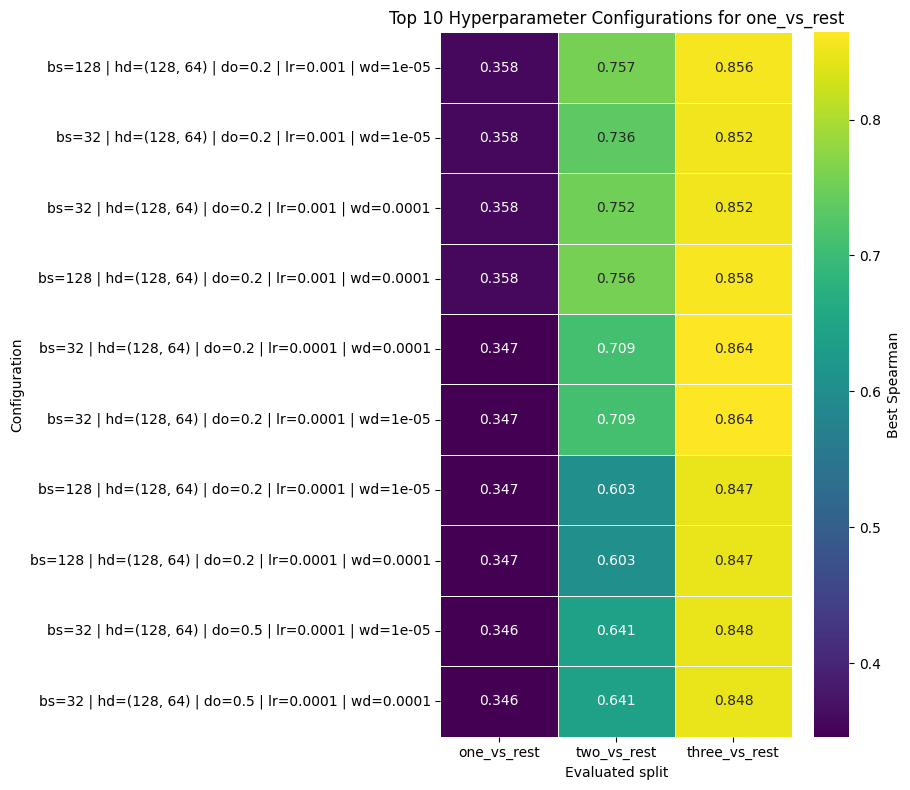

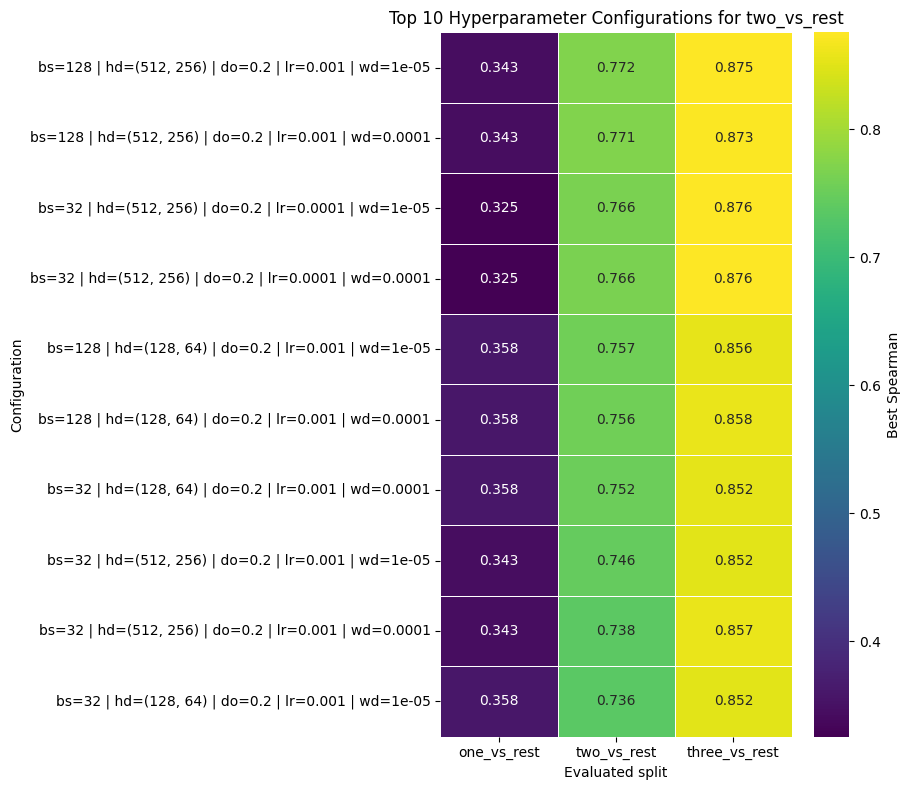

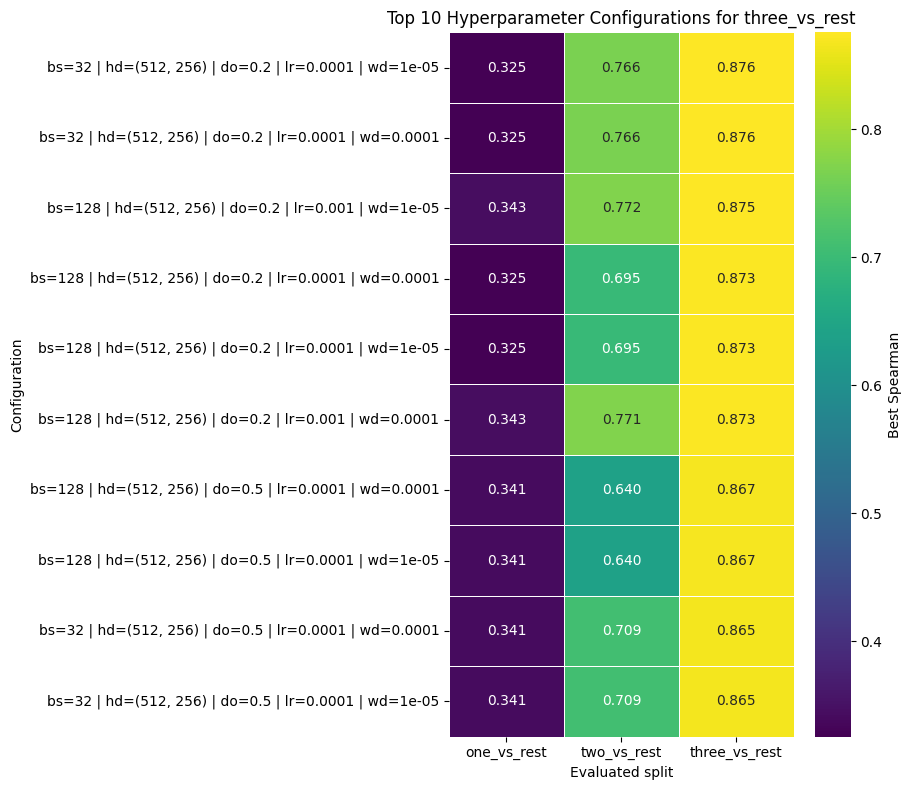

In [ ]:
for split in split_order:
    top10_split = top10_by_split_best[split].copy()

    heatmap_df = top10_split.set_index("config_label")[
        [f"best_spearman_{s}" for s in split_order]
    ].rename(columns={
        f"best_spearman_one_vs_rest": "one_vs_rest",
        f"best_spearman_two_vs_rest": "two_vs_rest",
        f"best_spearman_three_vs_rest": "three_vs_rest"
    })

    plt.figure(figsize=(9, 0.6 * len(heatmap_df) + 2))
    ax = sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        linewidths=0.5,
        cbar_kws={"label": "Best Spearman"}
    )

    ax.set_title(f"Top 10 Hyperparameter Configurations for {split}")
    ax.set_xlabel("Evaluated split")
    ax.set_ylabel("Configuration")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
best_config_per_split = []

for split in split_order:
    col = f"best_spearman_{split}"
    row = config_summary.sort_values(col, ascending=False).iloc[0].copy()
    row["winning_split"] = split
    best_config_per_split.append(row)

best_config_per_split = pd.DataFrame(best_config_per_split)

display(
    best_config_per_split[
        ["winning_split"]
        + param_cols
        + ["config_label"]
        + [f"best_spearman_{s}" for s in split_order]
        + [f"last_spearman_{s}" for s in split_order]
    ]
)

,winning_split,train_batch_size,hidden_dims,dropout,lr,weight_decay,config_label,best_spearman_one_vs_rest,best_spearman_two_vs_rest,best_spearman_three_vs_rest,last_spearman_one_vs_rest,last_spearman_two_vs_rest,last_spearman_three_vs_rest
3,one_vs_rest,128,"(128, 64)",0.2,0.0010,0.00001,"bs=128 | hd=(128, 64) | do=0.2 | lr=0.001 | wd...",0.357772,0.756627,0.856282,0.314668,0.752658,0.841799
0,two_vs_rest,128,"(512, 256)",0.2,0.0010,0.00001,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.001 | w...",0.342835,0.772428,0.874651,0.313391,0.772428,0.867049
5,three_vs_rest,32,"(512, 256)",0.2,0.0001,0.00001,"bs=32 | hd=(512, 256) | do=0.2 | lr=0.0001 | w...",0.325340,0.765642,0.875829,0.209425,0.755923,0.873284


In [ ]:
best_model_overall = config_summary.iloc[0].copy()
display(best_model_overall)

,0
train_batch_size,128
hidden_dims,"(512, 256)"
dropout,0.2
lr,0.001
weight_decay,0.00001
config_label,"bs=128 | hd=(512, 256) | do=0.2 | lr=0.001 | w..."
best_spearman_one_vs_rest,0.342835
best_spearman_two_vs_rest,0.772428
best_spearman_three_vs_rest,0.874651
last_spearman_one_vs_rest,0.313391


In [ ]:
best_model_overall_last = config_summary.sort_values(
    "mean_last_across_splits",
    ascending=False
).iloc[0].copy()

display(best_model_overall_last)

KeyError: 'mean_last_across_splits'

In [ ]:
# merge split-aggregated config scores back to parameter settings
param_effect_df = config_summary.copy()

for col in ["train_batch_size", "hidden_dims", "dropout", "lr", "weight_decay"]:
    effect = (
        param_effect_df
        .groupby(col, as_index=False)[["mean_best_across_splits", "mean_last_across_splits"]]
        .mean()
        .sort_values("mean_best_across_splits", ascending=False)
    )
    print(f"\nParameter effect: {col}")
    display(effect)

split,one_vs_rest,two_vs_rest,three_vs_rest
train_batch_size,,,
32,0.340205,0.692309,0.838581
128,0.340205,0.676004,0.850516


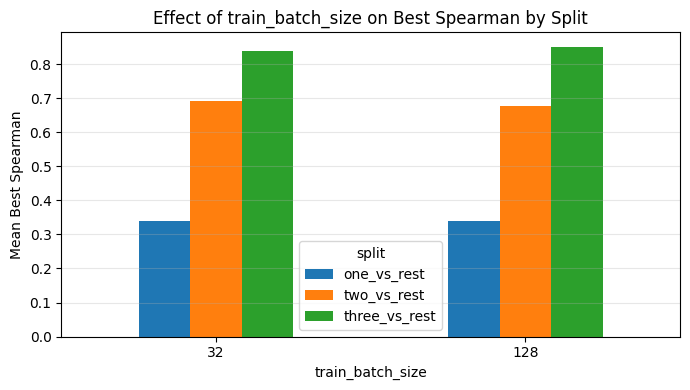

split,one_vs_rest,two_vs_rest,three_vs_rest
hidden_dims,,,
"(128, 64)",0.34417,0.660394,0.835590
"(512, 256)",0.33624,0.707919,0.853507


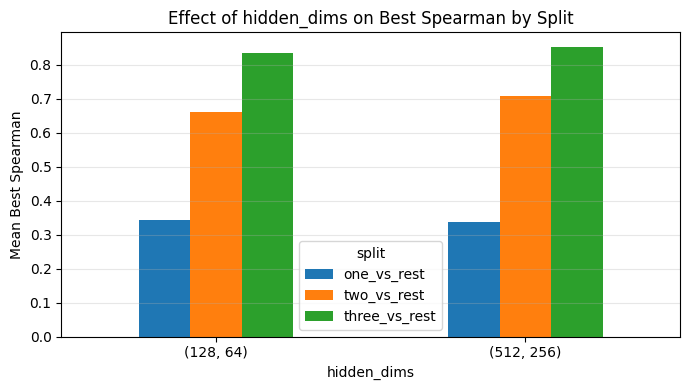

split,one_vs_rest,two_vs_rest,three_vs_rest
dropout,,,
0.2,0.343242,0.723398,0.862246
0.5,0.337168,0.644915,0.826850


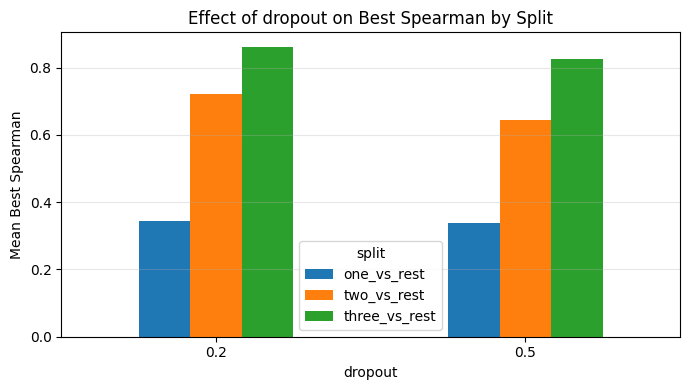

split,one_vs_rest,two_vs_rest,three_vs_rest
lr,,,
0.0001,0.33980,0.666644,0.859572
0.0010,0.34061,0.701668,0.829525


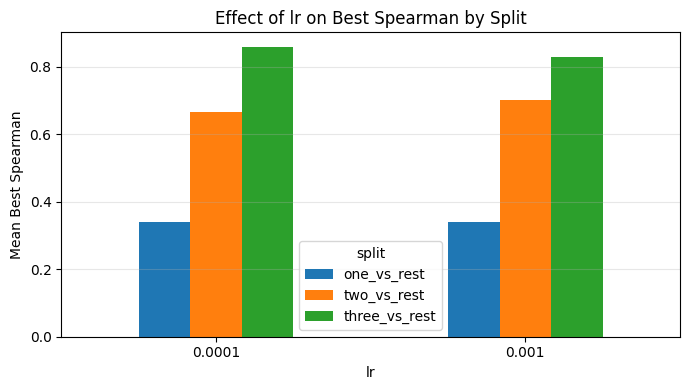

split,one_vs_rest,two_vs_rest,three_vs_rest
weight_decay,,,
0.00001,0.340205,0.686765,0.843794
0.00010,0.340205,0.681547,0.845303


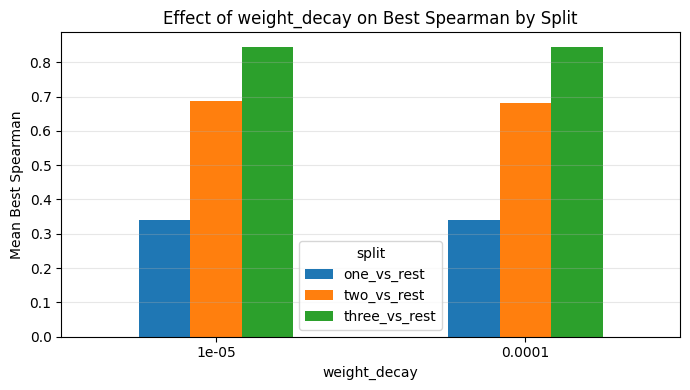

In [ ]:
param_names = ["train_batch_size", "hidden_dims", "dropout", "lr", "weight_decay"]

for col in param_names:
    effect = (
        plot_df
        .groupby([col, "split"], as_index=False)["best_spearman"]
        .mean()
    )

    effect_pivot = effect.pivot(
        index=col,
        columns="split",
        values="best_spearman"
    ).reindex(columns=split_order)

    display(effect_pivot)

    effect_pivot.plot(kind="bar", figsize=(7, 4))
    plt.title(f"Effect of {col} on Best Spearman by Split")
    plt.xlabel(col)
    plt.ylabel("Mean Best Spearman")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
best_config = config_summary.iloc[0][param_cols].to_dict()
print("Best config:", best_config)

local_effects = {}

for param in param_cols:
    mask = pd.Series(True, index=plot_df.index)
    for other_param in param_cols:
        if other_param != param:
            mask &= (plot_df[other_param] == best_config[other_param])

    local_df = plot_df[mask].copy()

    effect = (
        local_df
        .groupby([param, "split"], as_index=False)["best_spearman"]
        .mean()
    )

    local_effects[param] = effect
    print(f"\nLocal effect of {param} around best config")
    display(effect)

Best config: {'train_batch_size': 128, 'hidden_dims': '(512, 256)', 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 1e-05}

Local effect of train_batch_size around best config


,train_batch_size,split,best_spearman
0,32,one_vs_rest,0.342835
1,32,three_vs_rest,0.852063
2,32,two_vs_rest,0.745963
3,128,one_vs_rest,0.342835
4,128,three_vs_rest,0.874651
5,128,two_vs_rest,0.772428



Local effect of hidden_dims around best config


,hidden_dims,split,best_spearman
0,"(128, 64)",one_vs_rest,0.357772
1,"(128, 64)",three_vs_rest,0.856282
2,"(128, 64)",two_vs_rest,0.756627
3,"(512, 256)",one_vs_rest,0.342835
4,"(512, 256)",three_vs_rest,0.874651
5,"(512, 256)",two_vs_rest,0.772428



Local effect of dropout around best config


,dropout,split,best_spearman
0,0.2,one_vs_rest,0.342835
1,0.2,three_vs_rest,0.874651
2,0.2,two_vs_rest,0.772428
3,0.5,one_vs_rest,0.335933
4,0.5,three_vs_rest,0.836897
5,0.5,two_vs_rest,0.710322



Local effect of lr around best config


,lr,split,best_spearman
0,0.0001,one_vs_rest,0.325340
1,0.0001,three_vs_rest,0.873312
2,0.0001,two_vs_rest,0.695488
3,0.0010,one_vs_rest,0.342835
4,0.0010,three_vs_rest,0.874651
5,0.0010,two_vs_rest,0.772428



Local effect of weight_decay around best config


,weight_decay,split,best_spearman
0,0.00001,one_vs_rest,0.342835
1,0.00001,three_vs_rest,0.874651
2,0.00001,two_vs_rest,0.772428
3,0.00010,one_vs_rest,0.342835
4,0.00010,three_vs_rest,0.873104
5,0.00010,two_vs_rest,0.770882


In [ ]:
plot_df["best_minus_last"] = plot_df["best_spearman"] - plot_df["last_spearman"]

gap_summary = (
    plot_df
    .pivot_table(
        index=param_cols + ["config_label"],
        columns="split",
        values="best_minus_last",
        aggfunc="mean"
    )
    .reset_index()
)

gap_summary.columns = [
    f"{a}_{b}" if b != "" else a
    for a, b in gap_summary.columns.to_flat_index()
]

gap_summary["mean_gap_for_sort"] = gap_summary[
    [f"best_minus_last_{s}" for s in split_order]
].mean(axis=1)

gap_summary = gap_summary.sort_values(
    "mean_gap_for_sort",
    ascending=False
).reset_index(drop=True)

display(gap_summary.head(10))

ValueError: too many values to unpack (expected 2)

In [ ]:
gap_by_split = (
    plot_df
    .groupby("split", as_index=False)["best_minus_last"]
    .mean()
)

display(gap_by_split)

,split,best_minus_last
0,one_vs_rest,0.091940
1,three_vs_rest,0.052287
2,two_vs_rest,0.073679


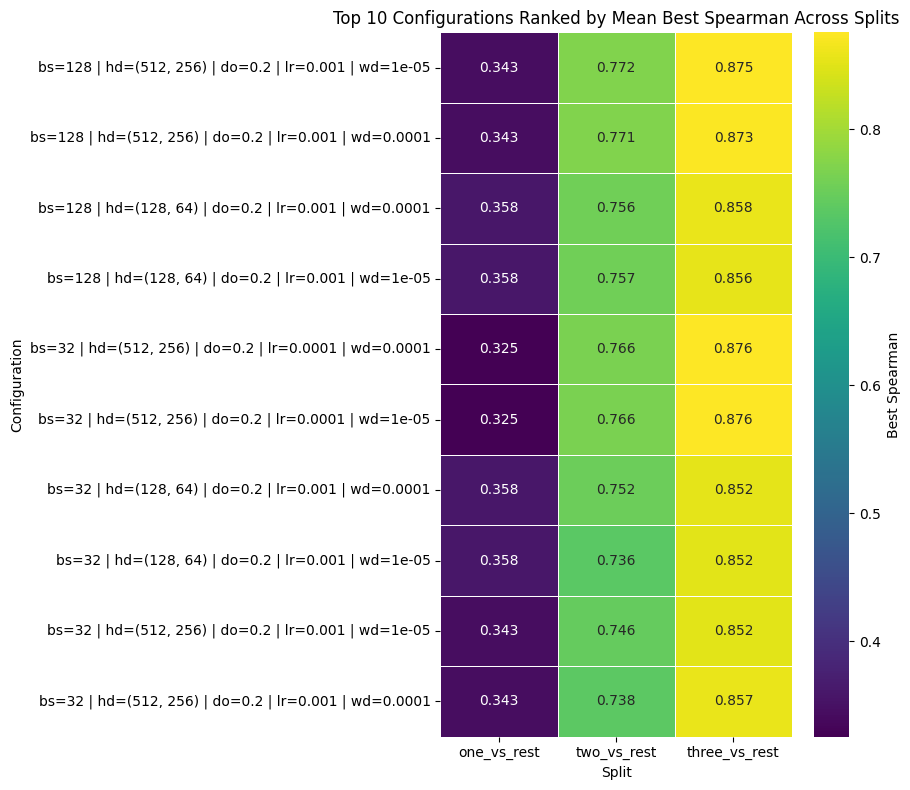

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

best_cols = [f"best_spearman_{s}" for s in split_order]

heatmap_all = config_summary.copy()
heatmap_all["mean_best_across_splits"] = heatmap_all[best_cols].mean(axis=1)

heatmap_all = heatmap_all.sort_values(
    "mean_best_across_splits",
    ascending=False
).reset_index(drop=True)

top_n = 10
heatmap_top = heatmap_all.head(top_n).copy()

heatmap_df = heatmap_top.set_index("config_label")[best_cols].rename(columns={
    "best_spearman_one_vs_rest": "one_vs_rest",
    "best_spearman_two_vs_rest": "two_vs_rest",
    "best_spearman_three_vs_rest": "three_vs_rest"
})

plt.figure(figsize=(9, 0.6 * len(heatmap_df) + 2))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Best Spearman"}
)

ax.set_title(f"Top {top_n} Configurations Ranked by Mean Best Spearman Across Splits")
ax.set_xlabel("Split")
ax.set_ylabel("Configuration")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()